# 1. Daten importieren PyCharm


In [64]:
import pandas as pd

df = pd.read_csv("verbrauch.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16830 entries, 0 to 16829
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   zaehler_id                        16830 non-null  object 
 1   kunde_id                          16830 non-null  object 
 2   kundentyp                         16830 non-null  object 
 3   vertragsleistung_kw               16830 non-null  int64  
 4   monat                             16830 non-null  object 
 5   monat_idx                         16830 non-null  int64  
 6   arbeitstage                       16830 non-null  int64  
 7   feiertage_im_monat                16830 non-null  int64  
 8   mittlere_temperatur_c             16325 non-null  float64
 9   heiztage                          16830 non-null  int64  
 10  produktionsplan_index             16157 non-null  float64
 11  wartung_aktiv                     16830 non-null  int64  
 12  vorm

# 2. Einzigartige Werte in jeder Spalte anzeigen


In [65]:
for column in df.columns:
    print(column, df[column].unique())

zaehler_id ['ZL-00000' 'ZL-00001' 'ZL-00002' 'ZL-00003' 'ZL-00004' 'ZL-00005'
 'ZL-00006' 'ZL-00007' 'ZL-00008' 'ZL-00009' 'ZL-00010' 'ZL-00011'
 'ZL-00012' 'ZL-00013' 'ZL-00014' 'ZL-00015' 'ZL-00016' 'ZL-00017'
 'ZL-00018' 'ZL-00019' 'ZL-00020' 'ZL-00021' 'ZL-00022' 'ZL-00023'
 'ZL-00024' 'ZL-00025' 'ZL-00026' 'ZL-00027' 'ZL-00028' 'ZL-00029'
 'ZL-00030' 'ZL-00031' 'ZL-00032' 'ZL-00033' 'ZL-00034' 'ZL-00035'
 'ZL-00036' 'ZL-00037' 'ZL-00038' 'ZL-00039' 'ZL-00040' 'ZL-00041'
 'ZL-00042' 'ZL-00043' 'ZL-00044' 'ZL-00045' 'ZL-00046' 'ZL-00047'
 'ZL-00048' 'ZL-00049' 'ZL-00050' 'ZL-00051' 'ZL-00052' 'ZL-00053'
 'ZL-00054' 'ZL-00055' 'ZL-00056' 'ZL-00057' 'ZL-00058' 'ZL-00059'
 'ZL-00060' 'ZL-00061' 'ZL-00062' 'ZL-00063' 'ZL-00064' 'ZL-00065'
 'ZL-00066' 'ZL-00067' 'ZL-00068' 'ZL-00069' 'ZL-00070' 'ZL-00071'
 'ZL-00072' 'ZL-00073' 'ZL-00074' 'ZL-00075' 'ZL-00076' 'ZL-00077'
 'ZL-00078' 'ZL-00079' 'ZL-00080' 'ZL-00081' 'ZL-00082' 'ZL-00083'
 'ZL-00084' 'ZL-00085' 'ZL-00086' 'ZL-00087' 'ZL-00

# 3. Werte in der Spalte „kundentyp“ formatieren

In [66]:
mapping = {
    "gewerbe": "Gewerbe",
    "gewerbekunde": "Gewerbe",
    "industrie": "Industrie",
    "industriekunde": "Industrie",
    "kommunal": "Kommunal",
    "kommune": "Kommunal",
    "behoerde": "Kommunal"
}

df["kundentyp"] = (
    df["kundentyp"]
    .str.strip()
    .str.lower()
    .replace(mapping)
    .str.capitalize()
)

In [67]:
print(df["kundentyp"].unique())


['Gewerbe' 'Kommunal' 'Industrie']


# 4. Die Werte in der Spalte „monat“ in ein einheitliches maschinenlesbares Format (YYYY-MM) bringen und die Übereinstimmung des Monats in der Spalte „monat“ mit dem Monat in der Spalte „monat_idx“ überprüfen.

In [68]:

# 1. Monat in das maschinenlesbare Format YYYY-MM umwandeln
def clean_month(value):
    if pd.isna(value):
        return None

    value = str(value).strip()

    # Format YYYY-MM
    if len(value) == 7 and value[4] == "-":
        year, month = value.split("-")

    # Format MM/YYYY
    elif "/" in value:
        month, year = value.split("/")

    # Format MM.YYYY
    elif "." in value:
        month, year = value.split(".")

    else:
        return None

    # Überprüfen, ob Jahr und Monat aus Zahlen bestehen
    if not (year.isdigit() and month.isdigit()):
        return None

    month = int(month)
    year = int(year)

    # Gültigkeit des Monats überprüfen
    if not 1 <= month <= 12:
        return None

    # Plausiblen Jahresbereich überprüfen
    if not 1900 <= year <= 2100:
        return None

    # In das maschinenlesbare Format YYYY-MM umwandeln
    return f"{year:04d}-{month:02d}"


# 2. Bereinigte Monatsspalte erstellen
df["monat_clean"] = df["monat"].apply(clean_month)


# 3. Fehlerhafte Monatswerte überprüfen
print("Fehlerhafte Daten:")
print(
    df[df["monat_clean"].isna()][["monat"]]
)


# 4. YYYY-MM in ein Datum umwandeln

# Der erste Tag des Monats wird als technische Darstellung des Monats verwendet
df["monat_date"] = pd.to_datetime(
    df["monat_clean"],
    format="%Y-%m",
    errors="coerce"
)



# 5. Monatsnummer extrahieren
df["monat_num"] = df["monat_date"].dt.month



# 6. Monat mit Monat_idx vergleichen
print("\nAbweichungen Monat / Monat_idx:")

print(
    df[
        df["monat_num"].notna()
        & (df["monat_num"] != df["monat_idx"])
    ][
        ["monat", "monat_clean", "monat_idx", "monat_num"]
    ]
)



# 7. Ursprüngliche Monatsspalte durch das maschinenlesbare Format ersetzen
df["monat"] = df["monat_clean"]


# 8. Hilfsspalten entfernen
df.drop(
    columns=["monat_clean", "monat_date", "monat_num"],
    inplace=True
)

Fehlerhafte Daten:
Empty DataFrame
Columns: [monat]
Index: []

Abweichungen Monat / Monat_idx:
Empty DataFrame
Columns: [monat, monat_clean, monat_idx, monat_num]
Index: []


In [69]:
print(df["monat"].unique())

['2024-01' '2024-02' '2024-03' '2024-04' '2024-05' '2024-06' '2024-07'
 '2024-08' '2024-09' '2024-10' '2024-11' '2024-12' '2025-01' '2025-02'
 '2025-03' '2025-04' '2025-05' '2025-06' '2025-07' '2025-08' '2025-09'
 '2025-10' '2025-11' '2025-12']


# 5. Vollständige Duplikate finden und entfernen


In [70]:
df.duplicated().sum()
df = df.drop_duplicates()

In [71]:
df = df.drop_duplicates()

Ergebnis: Es wurden 30 vollständige Duplikate gefunden und entfernt.

# 6. Prüfen, ob logische Duplikate vorhanden sind.

In [72]:
dups = (
    df.groupby(
        ["kunde_id", "zaehler_id", "monat"]
    )
    .size()
    .reset_index(name="count")
)

print(
    dups[dups["count"] > 1]
)

Empty DataFrame
Columns: [kunde_id, zaehler_id, monat, count]
Index: []


Ergebnis: Es wurden keine logische Duplikate gefunden.

# 7. Die Datenstruktur nach der Korrektur offensichtlicher Fehler überprüfen.


In [73]:

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 16799
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   zaehler_id                        16800 non-null  object 
 1   kunde_id                          16800 non-null  object 
 2   kundentyp                         16800 non-null  object 
 3   vertragsleistung_kw               16800 non-null  int64  
 4   monat                             16800 non-null  object 
 5   monat_idx                         16800 non-null  int64  
 6   arbeitstage                       16800 non-null  int64  
 7   feiertage_im_monat                16800 non-null  int64  
 8   mittlere_temperatur_c             16296 non-null  float64
 9   heiztage                          16800 non-null  int64  
 10  produktionsplan_index             16128 non-null  float64
 11  wartung_aktiv                     16800 non-null  int64  
 12  vormonat_

In [74]:
print(df.isna().sum())

zaehler_id                             0
kunde_id                               0
kundentyp                              0
vertragsleistung_kw                    0
monat                                  0
monat_idx                              0
arbeitstage                            0
feiertage_im_monat                     0
mittlere_temperatur_c                504
heiztage                               0
produktionsplan_index                672
wartung_aktiv                          0
vormonat_verbrauch_kwh               700
letzte_3_monate_durchschnitt_kwh       1
vorjahr_monat_verbrauch_kwh         8400
verbrauch_kwh                          0
dtype: int64


In [75]:
df.isna().mean() * 100

zaehler_id                           0.000000
kunde_id                             0.000000
kundentyp                            0.000000
vertragsleistung_kw                  0.000000
monat                                0.000000
monat_idx                            0.000000
arbeitstage                          0.000000
feiertage_im_monat                   0.000000
mittlere_temperatur_c                3.000000
heiztage                             0.000000
produktionsplan_index                4.000000
wartung_aktiv                        0.000000
vormonat_verbrauch_kwh               4.166667
letzte_3_monate_durchschnitt_kwh     0.005952
vorjahr_monat_verbrauch_kwh         50.000000
verbrauch_kwh                        0.000000
dtype: float64

In [76]:
df.nunique()


zaehler_id                            700
kunde_id                              700
kundentyp                               3
vertragsleistung_kw                   271
monat                                  24
monat_idx                              12
arbeitstage                             4
feiertage_im_monat                      3
mittlere_temperatur_c                 269
heiztage                              204
produktionsplan_index                 701
wartung_aktiv                           2
vormonat_verbrauch_kwh              13308
letzte_3_monate_durchschnitt_kwh    15844
vorjahr_monat_verbrauch_kwh          7553
verbrauch_kwh                       13969
dtype: int64

# 8. Die Spalte „vorjahr_monat_verbrauch_kwh“ analysieren.



In [77]:
df["monat"].str[:4].unique()

array(['2024', '2025'], dtype=object)

In [78]:
df["jahr"] = df["monat"].str[:4].astype(int)

print(
    df.groupby("jahr")["vorjahr_monat_verbrauch_kwh"]
      .apply(lambda x: x.isna().sum())
)

jahr
2024    8400
2025       0
Name: vorjahr_monat_verbrauch_kwh, dtype: int64


In [79]:
print(
    df.groupby("jahr")["vorjahr_monat_verbrauch_kwh"]
      .agg(
          anzahl="size",
          nan_anzahl=lambda x: x.isna().sum(),
          nan_prozent=lambda x: x.isna().mean() * 100
      )
)

      anzahl  nan_anzahl  nan_prozent
jahr                                 
2024    8400        8400        100.0
2025    8400           0          0.0


**Analyse:**
Die Variable vorjahr_monat_verbrauch_kwh weist einen hohen Anteil fehlender Werte auf (ca. 50 %). Die fehlenden Werte betreffen überwiegend das Jahr 2024 und sind sachlich dadurch begründet, dass der Datensatz erst im Jahr 2024 beginnt und somit die entsprechenden Vorjahresmonate aus 2023 nicht vorliegen. Für das Jahr 2025 sind die Vorjahreswerte dagegen verfügbar.



**Entscheidung für EDA und Modellierung:**
Die Variable wird im bereinigten Datensatz beibehalten und im Rahmen der EDA analysiert, da sie grundsätzlich eine relevante historische Information zur Erklärung des Verbrauchs darstellt. Für die Modellierung wird sie jedoch nicht als Prädiktor verwendet, da der zeitliche Train/Test-Split auf 2024 (Training) und 2025 (Test) basiert. Im Trainingszeitraum stehen die Werte für 2024 überwiegend nicht zur Verfügung. Eine künstliche Imputation der fehlenden Werte würde zu einer ungleichen Informationsbasis zwischen Training und Test führen und die Modellbewertung verzerren.

# 9. Statistische Kennzahlen für alle Spalten der Tabelle anzeigen.


In [80]:
print(df.describe())


       vertragsleistung_kw     monat_idx   arbeitstage  feiertage_im_monat  \
count         16800.000000  16800.000000  16800.000000        16800.000000   
mean            142.611429      6.500000     21.791667            0.583333   
std             147.491224      3.452155      1.040030            0.640115   
min              20.000000      1.000000     20.000000            0.000000   
25%              49.000000      3.750000     21.000000            0.000000   
50%              82.000000      6.500000     22.000000            0.500000   
75%             186.000000      9.250000     23.000000            1.000000   
max            1067.000000     12.000000     23.000000            2.000000   

       mittlere_temperatur_c      heiztage  produktionsplan_index  \
count           16296.000000  16800.000000           16128.000000   
mean               10.144134    180.924583               1.000244   
std                 6.583775    151.234583               0.132855   
min                -4

In [81]:
print(df.describe(include="all"))


       zaehler_id   kunde_id kundentyp  vertragsleistung_kw    monat  \
count       16800      16800     16800         16800.000000    16800   
unique        700        700         3                  NaN       24   
top      ZL-00000  KD-221958   Gewerbe                  NaN  2024-01   
freq           24         24      9024                  NaN      700   
mean          NaN        NaN       NaN           142.611429      NaN   
std           NaN        NaN       NaN           147.491224      NaN   
min           NaN        NaN       NaN            20.000000      NaN   
25%           NaN        NaN       NaN            49.000000      NaN   
50%           NaN        NaN       NaN            82.000000      NaN   
75%           NaN        NaN       NaN           186.000000      NaN   
max           NaN        NaN       NaN          1067.000000      NaN   

           monat_idx   arbeitstage  feiertage_im_monat  mittlere_temperatur_c  \
count   16800.000000  16800.000000        16800.000000

# 10. Die Spalte „mittlere_temperatur_c“ analysieren.




In [82]:
print(
    df[df["mittlere_temperatur_c"].isna()]
    .groupby("monat")
    .size()
)

monat
2024-01    15
2024-02    19
2024-03    24
2024-04    15
2024-05    25
2024-06    36
2024-07    25
2024-08    25
2024-09    18
2024-10    24
2024-11    24
2024-12    20
2025-01    13
2025-02    27
2025-03    22
2025-04    23
2025-05    21
2025-06    18
2025-07    20
2025-08    22
2025-09    20
2025-10    15
2025-11    18
2025-12    15
dtype: int64


In [83]:
print(
    df.groupby("jahr")["mittlere_temperatur_c"]
      .apply(lambda x: x.isna().sum())
)

jahr
2024    270
2025    234
Name: mittlere_temperatur_c, dtype: int64


In [84]:
print(
    df.groupby("jahr")["mittlere_temperatur_c"]
      .apply(lambda x: x.isna().mean() * 100)
)

jahr
2024    3.214286
2025    2.785714
Name: mittlere_temperatur_c, dtype: float64


In [85]:
print(
    df[df["mittlere_temperatur_c"].isna()]
    .groupby("zaehler_id")
    .size()
    .sort_values(ascending=False)
)

zaehler_id
ZL-00307    6
ZL-00469    4
ZL-00573    4
ZL-00330    4
ZL-00511    4
           ..
ZL-00238    1
ZL-00236    1
ZL-00235    1
ZL-00232    1
ZL-00699    1
Length: 368, dtype: int64


In [86]:
analyse_temp = df.groupby("monat")["mittlere_temperatur_c"].agg(
    anzahl="size",
    nan_anzahl=lambda x: x.isna().sum(),
    nan_prozent=lambda x: x.isna().mean() * 100
)

print(analyse_temp)

         anzahl  nan_anzahl  nan_prozent
monat                                   
2024-01     700          15     2.142857
2024-02     700          19     2.714286
2024-03     700          24     3.428571
2024-04     700          15     2.142857
2024-05     700          25     3.571429
2024-06     700          36     5.142857
2024-07     700          25     3.571429
2024-08     700          25     3.571429
2024-09     700          18     2.571429
2024-10     700          24     3.428571
2024-11     700          24     3.428571
2024-12     700          20     2.857143
2025-01     700          13     1.857143
2025-02     700          27     3.857143
2025-03     700          22     3.142857
2025-04     700          23     3.285714
2025-05     700          21     3.000000
2025-06     700          18     2.571429
2025-07     700          20     2.857143
2025-08     700          22     3.142857
2025-09     700          20     2.857143
2025-10     700          15     2.142857
2025-11     700 

In [87]:
analyse_temp = df.groupby("monat").agg(
    anzahl=("mittlere_temperatur_c", "size"),
    nan_anzahl=("mittlere_temperatur_c", lambda x: x.isna().sum()),
    nan_prozent=("mittlere_temperatur_c", lambda x: x.isna().mean() * 100),
    mittelwert=("mittlere_temperatur_c", "mean")
)

print(analyse_temp)

         anzahl  nan_anzahl  nan_prozent  mittelwert
monat                                               
2024-01     700          15     2.142857    0.932993
2024-02     700          19     2.714286    2.021292
2024-03     700          24     3.428571    6.033876
2024-04     700          15     2.142857    9.996496
2024-05     700          25     3.571429   13.999111
2024-06     700          36     5.142857   17.098042
2024-07     700          25     3.571429   19.118519
2024-08     700          25     3.571429   18.925481
2024-09     700          18     2.571429   15.008211
2024-10     700          24     3.428571   10.873077
2024-11     700          24     3.428571    6.043639
2024-12     700          20     2.857143    2.002206
2025-01     700          13     1.857143    1.010480
2025-02     700          27     3.857143    2.034770
2025-03     700          22     3.142857    5.962389
2025-04     700          23     3.285714   10.017578
2025-05     700          21     3.000000   13.

In [88]:
print(
    df.groupby("monat")["mittlere_temperatur_c"]
      .nunique(dropna=True)
)

monat
2024-01    74
2024-02    77
2024-03    76
2024-04    78
2024-05    82
2024-06    72
2024-07    78
2024-08    75
2024-09    76
2024-10    78
2024-11    75
2024-12    73
2025-01    80
2025-02    77
2025-03    75
2025-04    81
2025-05    76
2025-06    78
2025-07    73
2025-08    80
2025-09    76
2025-10    76
2025-11    79
2025-12    76
Name: mittlere_temperatur_c, dtype: int64


In [89]:
print(
    df.groupby("kundentyp")["mittlere_temperatur_c"]
    .agg(
        anzahl="size",
        nan_anzahl=lambda x: x.isna().sum(),
        nan_prozent=lambda x: x.isna().mean() * 100
    )
)

           anzahl  nan_anzahl  nan_prozent
kundentyp                                 
Gewerbe      9024         272     3.014184
Industrie    5424         159     2.931416
Kommunal     2352          73     3.103741


In [90]:
print(
    df[["mittlere_temperatur_c", "heiztage"]].corr()
)

                       mittlere_temperatur_c  heiztage
mittlere_temperatur_c               1.000000 -0.991413
heiztage                           -0.991413  1.000000


Zwischen mittlere_temperatur_c und heiztage besteht eine sehr starke negative Korrelation (r = −0,991).

Falls Heiztage unabhängig von der mittleren Temperatur ermittelt wurden, könnte geprüft werden, ob sich die fehlenden Werte von mittlere_temperatur_c anhand der Variable Heiztage rekonstruieren lassen.

In [91]:
print(
    df[["mittlere_temperatur_c", "heiztage"]]
    .dropna()
    .drop_duplicates()
    .sort_values("mittlere_temperatur_c")
    .to_string(index=False)
)

 mittlere_temperatur_c  heiztage
                  -4.6       540
                  -4.1       528
                  -3.3       508
                  -3.2       505
                  -3.1       503
                  -2.9       497
                  -2.8       495
                  -2.7       492
                  -2.6       490
                  -2.4       485
                  -2.3       482
                  -2.2       480
                  -2.1       478
                  -2.0       475
                  -1.9       472
                  -1.8       470
                  -1.7       468
                  -1.6       465
                  -1.5       462
                  -1.4       460
                  -1.3       458
                  -1.2       455
                  -1.1       453
                  -1.0       450
                  -0.9       447
                  -0.8       445
                  -0.7       442
                  -0.6       440
                  -0.5       438
          

In [92]:
heiztage_monat = (
    df.groupby(["jahr", "monat_idx"])["heiztage"]
      .mean()
      .reset_index()
)

monat_namen = [
    "Januar", "Februar", "März", "April", "Mai", "Juni",
    "Juli", "August", "September", "Oktober", "November", "Dezember"
]

print(heiztage_monat)

    jahr  monat_idx    heiztage
0   2024          1  402.080000
1   2024          2  374.505714
2   2024          3  274.132857
3   2024          4  174.942857
4   2024          5   75.362857
5   2024          6   13.125714
6   2024          7    1.705714
7   2024          8    1.938571
8   2024          9   51.375714
9   2024         10  152.841429
10  2024         11  274.074286
11  2024         12  374.902857
12  2025          1  399.671429
13  2025          2  373.697143
14  2025          3  276.057143
15  2025          4  174.845714
16  2025          5   76.528571
17  2025          6   14.594286
18  2025          7    1.312857
19  2025          8    1.915714
20  2025          9   53.972857
21  2025         10  149.398571
22  2025         11  271.994286
23  2025         12  377.212857


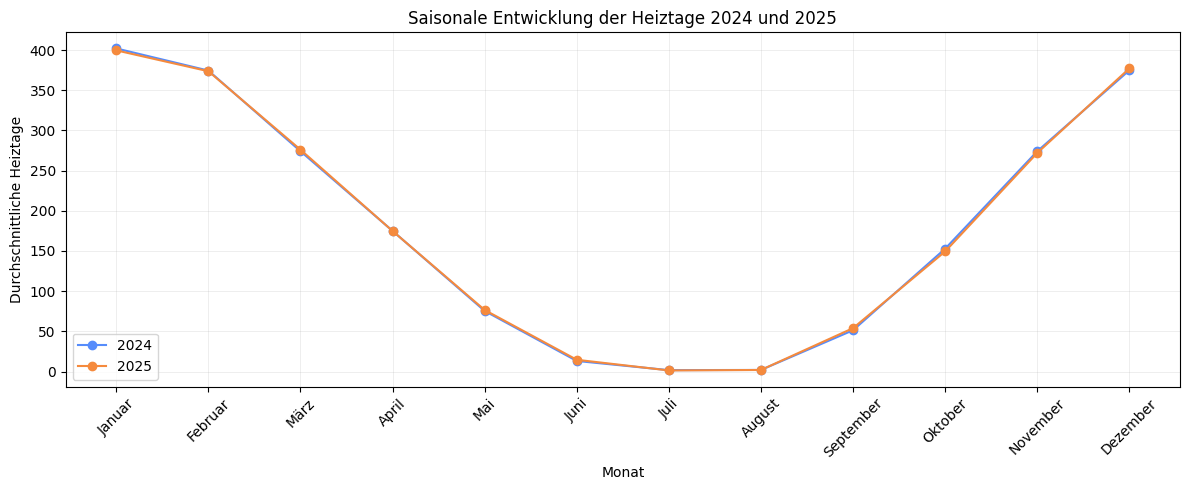

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for jahr in [2024, 2025]:
    daten = heiztage_monat[
        heiztage_monat["jahr"] == jahr
    ]

    plt.plot(
        daten["monat_idx"],
        daten["heiztage"],
        marker="o",
        label=str(jahr)
    )

plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Heiztage")
plt.title("Saisonale Entwicklung der Heiztage 2024 und 2025")
plt.xticks(range(1, 13), monat_namen, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Analyse:**

Die fehlenden Werte in mittlere_temperatur_c sind mit ca. 3 % relativ gering und gleichmäßig über Monate und Zähler verteilt. Es gibt keine starke Konzentration der fehlenden Werte auf bestimmte Monate oder Zähler.

**Entscheidung für EDA und Modellierung:**
Da die Variable als Einflussfaktor für den Verbrauch relevant ist, wird sie für die Modellierung beibehalten. Die fehlenden Werte werden nicht während der Datenbereinigung mit einem festen Wert ersetzt, sondern erst im Modellierungsprozess imputiert. Dadurch kann die Imputation ausschließlich auf Basis der Trainingsdaten erfolgen und eine Datenleckage vermieden werden.

# 11. Die Spalte „verbrauch_kwh“ analysieren.

In [94]:
print(df["verbrauch_kwh"].unique()[:100])

['8179.0' '7529.0' '6005.0' '6137.0' '8655.0' '6819.0' '6681.0' '6280.0'
 '5003.0' '5202.0' '6352.0' '5563.0' '8951.0' '7386.0' '5952.0' '6308.0'
 '6265.0' '5922.0' '6409.0' '5100.0' '3657.0' '6554.0' '6792.0' '5924.0'
 '24075.0' '20539.0' '20378.0' '15344.0' '22039.0' '17317.0' '17213.0'
 '16798.0' '9040.0' '18488.0' '18503.0' '21658.0' '15340.0' '15.673 MWh'
 '17939.0' '22967.0' '12002.0' '15607.0' '3569.4490599294927' '16457.0'
 '15905.0' '17921.0' '14558.0' '19530.0' '1674.7888999552185' '8477.0'
 '7776.0' '4980.0' '7192.0' '5648.0' '6731.0' '5693.0' '6316.0' '7672.0'
 '6645.0' '6624.0' '7807.0' '9110.0' '8928.0' '10212.0' '8812.0' '7289.0'
 '8033.0' '7014.0' '3838.0' '4679.0' '4461.0' '8450.0' '2935.0' '3107.0'
 '1853.0' '3257.0' '3175.0' '2230.0' '2405.0' '2143.0' '1782.0' '2147.0'
 '2619.0' '1882.0' '2846.0' '2879.0' '2711.0' '2924.0' '2800.0'
 '2.476 MWh' '2222.0' '2158.0' '2100.0' '2304.0' '2182.0' '2715.0'
 '17419.0' '15378.0' '19494.0' '2485.8994238616706']


In [95]:
print(df["verbrauch_kwh"].astype(str).str.contains("kWh", case=False, na=False).sum())
print(df["verbrauch_kwh"].astype(str).str.contains("MWh", case=False, na=False).sum())

0
672


In [96]:
print(
    df[df["verbrauch_kwh"].astype(str).str.contains("MWh", case=False, na=False)]
    [["verbrauch_kwh"]]
    .head(20)
)

    verbrauch_kwh
37     15.673 MWh
89      2.476 MWh
131    56.268 MWh
187     8.863 MWh
192    86.704 MWh
197    68.874 MWh
202    63.085 MWh
203    48.166 MWh
208    67.099 MWh
218     9.540 MWh
260     3.816 MWh
321    34.330 MWh
414    46.248 MWh
419    57.595 MWh
438     4.958 MWh
446     5.207 MWh
450     4.705 MWh
461    15.043 MWh
487    18.642 MWh
515     6.856 MWh


In [97]:
ohne_mwh = df[
    ~df["verbrauch_kwh"].astype(str).str.contains("MWh", case=False, na=False)
]

print(ohne_mwh["verbrauch_kwh"].head(20))

0     8179.0
1     7529.0
2     6005.0
3     6137.0
4     8655.0
5     6819.0
6     6681.0
7     6280.0
8     5003.0
9     5202.0
10    6352.0
11    5563.0
12    8951.0
13    7386.0
14    5952.0
15    6308.0
16    6265.0
17    5922.0
18    6409.0
19    5100.0
Name: verbrauch_kwh, dtype: object


In [98]:
df["verbrauch_original"] = df["verbrauch_kwh"]
df["verbrauch_kwh_clean"] = (
    df["verbrauch_kwh"]
    .astype(str)
    .str.strip()
)

# MWh → kWh
is_mwh = df["verbrauch_kwh_clean"].str.contains(
    "MWh",
    case=False,
    na=False
)

df.loc[is_mwh, "verbrauch_kwh_clean"] = (
    df.loc[is_mwh, "verbrauch_kwh_clean"]
    .str.replace("MWh", "", case=False, regex=False)
    .str.strip()
    .astype(float)
    * 1000
)

# Die übrigen Werte werden einfach in eine Zahl umgewandelt.
df["verbrauch_kwh_clean"] = pd.to_numeric(
    df["verbrauch_kwh_clean"],
    errors="coerce"
)

In [99]:
print(df[["verbrauch_kwh", "verbrauch_kwh_clean"]].head(50))


         verbrauch_kwh  verbrauch_kwh_clean
0               8179.0           8179.00000
1               7529.0           7529.00000
2               6005.0           6005.00000
3               6137.0           6137.00000
4               8655.0           8655.00000
5               6819.0           6819.00000
6               6681.0           6681.00000
7               6280.0           6280.00000
8               5003.0           5003.00000
9               5202.0           5202.00000
10              6352.0           6352.00000
11              5563.0           5563.00000
12              8951.0           8951.00000
13              7386.0           7386.00000
14              5952.0           5952.00000
15              6308.0           6308.00000
16              6265.0           6265.00000
17              5922.0           5922.00000
18              6409.0           6409.00000
19              5100.0           5100.00000
20              3657.0           3657.00000
21              6554.0          

In [100]:
print("NaN:", df["verbrauch_kwh_clean"].isna().sum())
print("Min:", df["verbrauch_kwh_clean"].min())
print("Max:", df["verbrauch_kwh_clean"].max())

NaN: 0
Min: -1000.0
Max: 675230.5702862408


In [101]:
print(
    df.loc[is_mwh, ["verbrauch_kwh", "verbrauch_kwh_clean"]]
    .head(20)
)

    verbrauch_kwh  verbrauch_kwh_clean
37     15.673 MWh              15673.0
89      2.476 MWh               2476.0
131    56.268 MWh              56268.0
187     8.863 MWh               8863.0
192    86.704 MWh              86704.0
197    68.874 MWh              68874.0
202    63.085 MWh              63085.0
203    48.166 MWh              48166.0
208    67.099 MWh              67099.0
218     9.540 MWh               9540.0
260     3.816 MWh               3816.0
321    34.330 MWh              34330.0
414    46.248 MWh              46248.0
419    57.595 MWh              57595.0
438     4.958 MWh               4958.0
446     5.207 MWh               5207.0
450     4.705 MWh               4705.0
461    15.043 MWh              15043.0
487    18.642 MWh              18642.0
515     6.856 MWh               6856.0


In [102]:
df["verbrauch_kwh"] = df["verbrauch_kwh_clean"]

df.drop(
    columns=["verbrauch_kwh_clean", "verbrauch_original"],
    inplace=True
)

In [103]:
print(
    df[df["verbrauch_kwh"] < 0][["verbrauch_kwh"]]
)

      verbrauch_kwh
6683          -50.0
6906        -1000.0


In [104]:
print(
    "Negative Verbräuche:",
    (df["verbrauch_kwh"] < 0).sum()
)

Negative Verbräuche: 2


In [105]:
print(
    "Fehlende Werte:",
    df["verbrauch_kwh"].isna().sum()
)

Fehlende Werte: 0


In [106]:
print(
    df.loc[
        df["verbrauch_kwh"] < 0
    ].T
)

                                          6683       6906
zaehler_id                            ZL-00278   ZL-00287
kunde_id                             KD-713333  KD-115708
kundentyp                              Gewerbe  Industrie
vertragsleistung_kw                         47        393
monat                                  2024-12    2025-07
monat_idx                                   12          7
arbeitstage                                 22         23
feiertage_im_monat                           2          0
mittlere_temperatur_c                      1.1       21.9
heiztage                                   398          0
produktionsplan_index                    0.905      0.992
wartung_aktiv                                0          0
vormonat_verbrauch_kwh            30875.576442    96068.0
letzte_3_monate_durchschnitt_kwh  15580.192147   110284.0
vorjahr_monat_verbrauch_kwh                NaN   116309.0
verbrauch_kwh                            -50.0    -1000.0
jahr          

In [107]:
negative = df[df["verbrauch_kwh"] < 0]

for zaehler in negative["zaehler_id"]:
    print("\nZähler:", zaehler)

    print(
        df[df["zaehler_id"] == zaehler]
        [["zaehler_id", "monat", "verbrauch_kwh"]]
        .sort_values("monat")
    )


Zähler: ZL-00278
     zaehler_id    monat  verbrauch_kwh
6672   ZL-00278  2024-01   13475.000000
6673   ZL-00278  2024-02   10952.000000
6674   ZL-00278  2024-03   11758.000000
6675   ZL-00278  2024-04   10633.000000
6676   ZL-00278  2024-05   10844.000000
6677   ZL-00278  2024-06    8556.000000
6678   ZL-00278  2024-07    9809.000000
6679   ZL-00278  2024-08    8092.000000
6680   ZL-00278  2024-09    6616.000000
6681   ZL-00278  2024-10    9249.000000
6682   ZL-00278  2024-11   30875.576442
6683   ZL-00278  2024-12     -50.000000
6684   ZL-00278  2025-01   10847.000000
6685   ZL-00278  2025-02    8572.000000
6686   ZL-00278  2025-03    6212.000000
6687   ZL-00278  2025-04   10659.000000
6688   ZL-00278  2025-05   10554.000000
6689   ZL-00278  2025-06    9233.000000
6690   ZL-00278  2025-07    8526.000000
6691   ZL-00278  2025-08    7835.000000
6692   ZL-00278  2025-09    7984.000000
6693   ZL-00278  2025-10    9462.000000
6694   ZL-00278  2025-11    8584.000000
6695   ZL-00278  2025-

In [108]:
df.loc[df["verbrauch_kwh"] < 0, "verbrauch_kwh"] = pd.NA


In [109]:
print("Negative Verbräuche:", (df["verbrauch_kwh"] < 0).sum())
print("Fehlende Werte:", df["verbrauch_kwh"].isna().sum())

Negative Verbräuche: 0
Fehlende Werte: 2


In [110]:
nullverbrauch = df[df["verbrauch_kwh"] == 0]

print("Anzahl 0-Werte:", len(nullverbrauch))
display(nullverbrauch)

Anzahl 0-Werte: 1


,zaehler_id,kunde_id,kundentyp,vertragsleistung_kw,monat,monat_idx,arbeitstage,feiertage_im_monat,mittlere_temperatur_c,heiztage,produktionsplan_index,wartung_aktiv,vormonat_verbrauch_kwh,letzte_3_monate_durchschnitt_kwh,vorjahr_monat_verbrauch_kwh,verbrauch_kwh,jahr
5250,ZL-00218,KD-502690,Gewerbe,20,2025-07,7,23,0,19.9,0,1.046,0,4138.0,4697.333333,3803.0,0.0,2025


In [111]:
df[df["verbrauch_kwh"] == 0].groupby("monat").size()

monat
2025-07    1
dtype: int64

In [112]:
df[df["verbrauch_kwh"] == 0].groupby("zaehler_id").size().sort_values(ascending=False)

zaehler_id
ZL-00218    1
dtype: int64

In [113]:
print(df[df["verbrauch_kwh"] == 0].T)

                                         5250
zaehler_id                           ZL-00218
kunde_id                            KD-502690
kundentyp                             Gewerbe
vertragsleistung_kw                        20
monat                                 2025-07
monat_idx                                   7
arbeitstage                                23
feiertage_im_monat                          0
mittlere_temperatur_c                    19.9
heiztage                                    0
produktionsplan_index                   1.046
wartung_aktiv                               0
vormonat_verbrauch_kwh                 4138.0
letzte_3_monate_durchschnitt_kwh  4697.333333
vorjahr_monat_verbrauch_kwh            3803.0
verbrauch_kwh                             0.0
jahr                                     2025


In [114]:
df.loc[df["verbrauch_kwh"] == 0, "verbrauch_kwh"] = pd.NA

In [115]:
print("0-Werte:", (df["verbrauch_kwh"] == 0).sum())
print("NaN-Werte:", df["verbrauch_kwh"].isna().sum())

0-Werte: 0
NaN-Werte: 3


In [116]:
df = df.sort_values(["zaehler_id", "monat"]).copy()

df["verbrauch_vormonat_berechnet"] = (
    df.groupby("zaehler_id")["verbrauch_kwh"]
      .shift(1)
)

In [117]:
vergleich = df[
    [
        "zaehler_id",
        "monat",
        "verbrauch_kwh",
        "vormonat_verbrauch_kwh",
        "verbrauch_vormonat_berechnet"
    ]
].copy()

vergleich["abweichung"] = (
    vergleich["vormonat_verbrauch_kwh"]
    - vergleich["verbrauch_vormonat_berechnet"]
)

print(
    vergleich[
        vergleich["abweichung"].abs() > 0.01
    ].to_string(index=False)
)

zaehler_id   monat  verbrauch_kwh  vormonat_verbrauch_kwh  verbrauch_vormonat_berechnet  abweichung
  ZL-00034 2024-05        15433.0            52755.508767                       52756.0   -0.491233
  ZL-00043 2025-05        43190.0             4011.750479                        4012.0   -0.249521
  ZL-00047 2025-05         6527.0            22952.636767                       22953.0   -0.363233
  ZL-00121 2025-09        10783.0            26916.747475                       26917.0   -0.252525
  ZL-00151 2025-11        80988.0            10259.639046                       10260.0   -0.360954
  ZL-00172 2025-02        54346.0           232652.081755                      232652.0    0.081755
  ZL-00184 2025-01        23028.0            74725.229881                       74725.0    0.229881
  ZL-00211 2025-10         4551.0             8148.083595                        8148.0    0.083595
  ZL-00285 2025-01        13551.0             3395.567425                        3396.0   -0.432575


In [118]:
vergleich = df[
    df["verbrauch_vormonat_berechnet"].notna()
    & df["vormonat_verbrauch_kwh"].notna()
].copy()

vergleich["differenz"] = (
    vergleich["vormonat_verbrauch_kwh"]
    - vergleich["verbrauch_vormonat_berechnet"]
)

print("Anzahl Vergleiche:", len(vergleich))
print("Abweichungen:", (vergleich["differenz"].abs() > 0.01).sum())
print("Maximale Abweichung:", vergleich["differenz"].abs().max())

Anzahl Vergleiche: 16097
Abweichungen: 16
Maximale Abweichung: 0.4912326359335566


In [119]:
df["verbrauch_kwh_original"] = df["verbrauch_kwh"]


In [120]:
df["monat"] = pd.to_datetime(df["monat"])

In [121]:
# Счётчики и месяцы, где verbrauch_kwh = NaN
nan_zeilen = df[df["verbrauch_kwh"].isna()][
    ["zaehler_id", "monat"]
].copy()

for _, row in nan_zeilen.iterrows():

    zaehler = row["zaehler_id"]
    nan_monat = row["monat"]

    # Daten des Zählers
    df_z = df[df["zaehler_id"] == zaehler].sort_values("monat").copy()

    # Monat vor, NaN-Monat und Monat danach
    zeilen = df_z[
        df_z["monat"].between(
            nan_monat - pd.DateOffset(months=1),
            nan_monat + pd.DateOffset(months=1)
        )
    ]

    print("\n" + "=" * 80)
    print(f"Zähler: {zaehler} | Fehlender Monat: {nan_monat.strftime('%Y-%m')}")
    print("=" * 80)

    print(
        zeilen[
            [
                "monat",
                "verbrauch_kwh",
                "vormonat_verbrauch_kwh",
                "verbrauch_vormonat_berechnet"
            ]
        ].to_string(index=False)
    )


Zähler: ZL-00218 | Fehlender Monat: 2025-07
     monat  verbrauch_kwh  vormonat_verbrauch_kwh  verbrauch_vormonat_berechnet
2025-06-01         4138.0                  5929.0                        5929.0
2025-07-01            NaN                  4138.0                        4138.0
2025-08-01         4299.0                  3620.0                           NaN

Zähler: ZL-00278 | Fehlender Monat: 2024-12
     monat  verbrauch_kwh  vormonat_verbrauch_kwh  verbrauch_vormonat_berechnet
2024-11-01   30875.576442             9249.000000                   9249.000000
2024-12-01            NaN            30875.576442                  30875.576442
2025-01-01   10847.000000            10043.000000                           NaN

Zähler: ZL-00287 | Fehlender Monat: 2025-07
     monat  verbrauch_kwh  vormonat_verbrauch_kwh  verbrauch_vormonat_berechnet
2025-06-01        96068.0                117918.0                      117918.0
2025-07-01            NaN                 96068.0                

In [122]:
df = df.sort_values(["zaehler_id", "monat"]).copy()

# Vormonat-Wert der nächsten Zeile
df["vormonat_naechster_monat"] = (
    df.groupby("zaehler_id")["vormonat_verbrauch_kwh"].shift(-1)
)

# Nur NaN in Verbrauch ersetzen
maske = (
    df["verbrauch_kwh"].isna()
    & df["vormonat_naechster_monat"].notna()
)

df.loc[maske, "verbrauch_kwh"] = (
    df.loc[maske, "vormonat_naechster_monat"]
)

In [123]:
print(
    df.loc[maske, [
        "zaehler_id",
        "monat",
        "verbrauch_kwh_original",
        "vormonat_verbrauch_kwh",
        "vormonat_naechster_monat",
        "verbrauch_kwh"
    ]].to_string(index=False)
)

zaehler_id      monat  verbrauch_kwh_original  vormonat_verbrauch_kwh  vormonat_naechster_monat  verbrauch_kwh
  ZL-00218 2025-07-01                     NaN             4138.000000                    3620.0         3620.0
  ZL-00278 2024-12-01                     NaN            30875.576442                   10043.0        10043.0
  ZL-00287 2025-07-01                     NaN            96068.000000                  106659.0       106659.0


In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 16799
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   zaehler_id                        16800 non-null  object        
 1   kunde_id                          16800 non-null  object        
 2   kundentyp                         16800 non-null  object        
 3   vertragsleistung_kw               16800 non-null  int64         
 4   monat                             16800 non-null  datetime64[ns]
 5   monat_idx                         16800 non-null  int64         
 6   arbeitstage                       16800 non-null  int64         
 7   feiertage_im_monat                16800 non-null  int64         
 8   mittlere_temperatur_c             16296 non-null  float64       
 9   heiztage                          16800 non-null  int64         
 10  produktionsplan_index             16128 non-null  f

In [125]:
df = df.sort_values(["zaehler_id", "monat"]).copy()

**Analyse:**
Die Variable verbrauch_kwh enthielt Werte in unterschiedlichen Einheiten und Formaten, darunter numerische Werte in kWh sowie Werte mit der Einheit MWh. Zusätzlich wurden zwei negative Verbrauchswerte und ein Wert von 0 festgestellt, die für den monatlichen Energieverbrauch als unplausibel bzw. fehlerhaft eingestuft wurden.

**Entscheidung für EDA und Modellierung:**
Alle Verbrauchswerte wurden einheitlich in kWh umgerechnet und anschließend numerisch gespeichert. Die zwei negativen Werte sowie der fehlerhafte Nullwert wurden durch NaN ersetzt. Da verbrauch_kwh die Zielvariable ist, werden die betroffenen Datensätze nicht für das Modelltraining verwendet. Statistische Ausreißer werden nicht automatisch entfernt, sondern separat analysiert.

# 12. Die Spalte „produktionsplan_index“ analysieren.


Der **produktionsplan_index** ist ein Kennwert, der die geplante Produktionsaktivität eines Monats im Verhältnis zu einem definierten Basisniveau beschreibt. Ein Wert von 1,0 entspricht dem normalen Produktionsniveau, während Werte über 1,0 eine höhere und Werte unter 1,0 eine niedrigere geplante Produktionsaktivität anzeigen.

In [126]:
print("Anzahl NaN:", df["produktionsplan_index"].isna().sum())
print("Prozent NaN:", df["produktionsplan_index"].isna().mean() * 100)

print("\nWerte:")
print(df["produktionsplan_index"].describe())

Anzahl NaN: 672
Prozent NaN: 4.0

Werte:
count    16128.000000
mean         1.000244
std          0.132855
min          0.579000
25%          0.899000
50%          1.000000
75%          1.100000
max          1.406000
Name: produktionsplan_index, dtype: float64


In [127]:
print(
    df["produktionsplan_index"]
    .dropna()
    .sort_values()
    .unique()[:20]
)

print(
    df["produktionsplan_index"]
    .dropna()
    .sort_values()
    .unique()[-20:]
)

[0.579 0.586 0.601 0.61  0.619 0.627 0.632 0.638 0.64  0.641 0.642 0.645
 0.647 0.648 0.649 0.652 0.653 0.66  0.661 0.662]
[1.342 1.343 1.344 1.345 1.346 1.347 1.348 1.351 1.353 1.356 1.358 1.362
 1.364 1.366 1.375 1.38  1.383 1.386 1.405 1.406]


In [128]:
# der durchschnittliche Produktionsplan-Index pro Monat
monat_mittel = (
    df.groupby("monat")["produktionsplan_index"]
      .mean()
      .reset_index()
)

display(monat_mittel)

,monat,produktionsplan_index
0,2024-01-01,1.072052
1,2024-02-01,1.126972
2,2024-03-01,1.145275
3,2024-04-01,1.127665
4,2024-05-01,1.073644
5,2024-06-01,1.001356
6,2024-07-01,0.924745
7,2024-08-01,0.866761
8,2024-09-01,0.850657
9,2024-10-01,0.864647


In [129]:
monat_mittel = (
    df.groupby("monat_idx")["produktionsplan_index"]
      .mean()
      .reset_index()
)

display(monat_mittel)

,monat_idx,produktionsplan_index
0,1,1.073672
1,2,1.129077
2,3,1.147801
3,4,1.132969
4,5,1.075555
5,6,1.000854
6,7,0.925914
7,8,0.868185
8,9,0.850236
9,10,0.868447


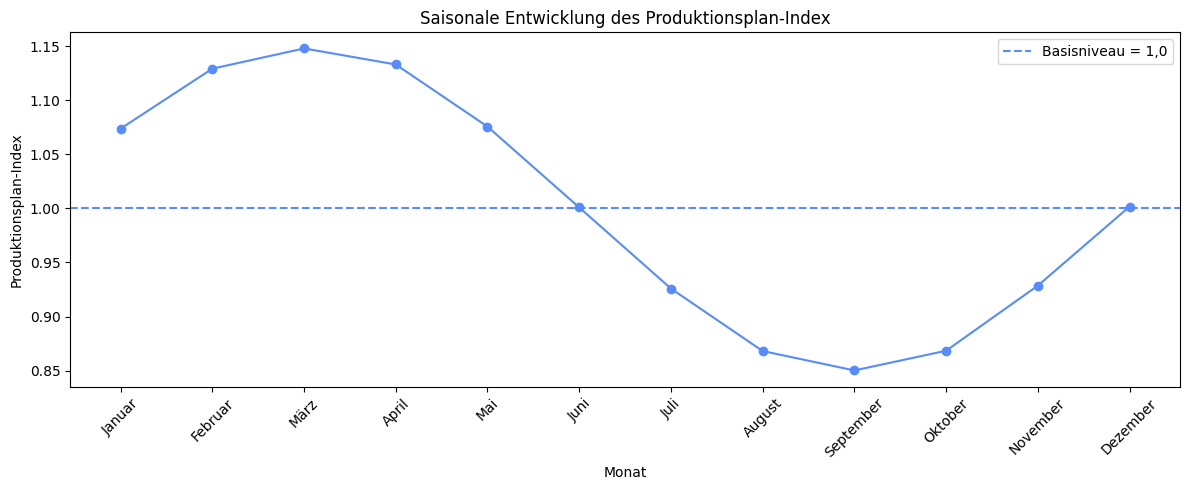

In [130]:
import matplotlib.pyplot as plt

monat_namen = [
    "Januar", "Februar", "März", "April", "Mai", "Juni",
    "Juli", "August", "September", "Oktober", "November", "Dezember"
]

monat_mittel["monat_name"] = monat_mittel["monat_idx"].map(
    dict(enumerate(monat_namen, start=1))
)

plt.figure(figsize=(12, 5))

plt.plot(
    monat_mittel["monat_name"],
    monat_mittel["produktionsplan_index"],
    marker="o"
)

plt.axhline(
    1.0,
    linestyle="--",
    label="Basisniveau = 1,0"
)

plt.xlabel("Monat")
plt.ylabel("Produktionsplan-Index")
plt.title("Saisonale Entwicklung des Produktionsplan-Index")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

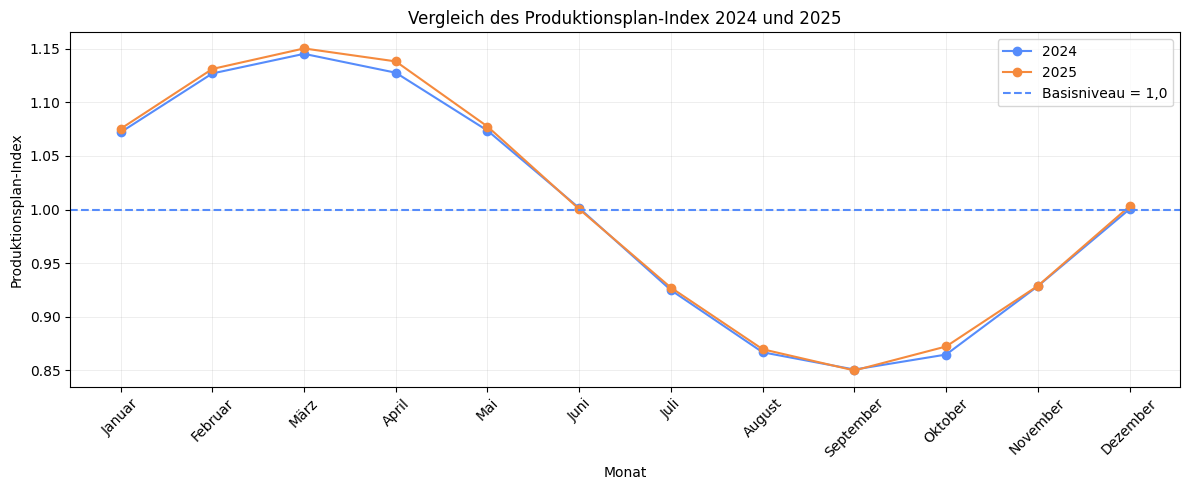

In [131]:
import matplotlib.pyplot as plt

# Durchschnittlicher Produktionsplan-Index nach Monaten und Jahren
monat_jahr = (
    df.groupby(["jahr", "monat_idx"])["produktionsplan_index"]
      .mean()
      .reset_index()
)

monat_namen = [
    "Januar", "Februar", "März", "April", "Mai", "Juni",
    "Juli", "August", "September", "Oktober", "November", "Dezember"
]

plt.figure(figsize=(12, 5))

for jahr in [2024, 2025]:
    daten = monat_jahr[monat_jahr["jahr"] == jahr]

    plt.plot(
        daten["monat_idx"],
        daten["produktionsplan_index"],
        marker="o",
        label=str(jahr)
    )

plt.axhline(
    1.0,
    linestyle="--",
    label="Basisniveau = 1,0"
)

plt.xlabel("Monat")
plt.ylabel("Produktionsplan-Index")
plt.title("Vergleich des Produktionsplan-Index 2024 und 2025")
plt.xticks(range(1, 13), monat_namen, rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [132]:
print(
    df.groupby("monat")["produktionsplan_index"]
      .agg(
          anzahl="size",
          nan_anzahl=lambda x: x.isna().sum(),
          nan_prozent=lambda x: x.isna().mean() * 100
      )
)

            anzahl  nan_anzahl  nan_prozent
monat                                      
2024-01-01     700          27     3.857143
2024-02-01     700          28     4.000000
2024-03-01     700          30     4.285714
2024-04-01     700          34     4.857143
2024-05-01     700          32     4.571429
2024-06-01     700          29     4.142857
2024-07-01     700          26     3.714286
2024-08-01     700          36     5.142857
2024-09-01     700          24     3.428571
2024-10-01     700          35     5.000000
2024-11-01     700          26     3.714286
2024-12-01     700          29     4.142857
2025-01-01     700          30     4.285714
2025-02-01     700          18     2.571429
2025-03-01     700          28     4.000000
2025-04-01     700          27     3.857143
2025-05-01     700          25     3.571429
2025-06-01     700          34     4.857143
2025-07-01     700          21     3.000000
2025-08-01     700          27     3.857143
2025-09-01     700          30  

In [133]:
print(
    df.groupby("kundentyp")["produktionsplan_index"]
      .agg(
          anzahl="size",
          nan_anzahl=lambda x: x.isna().sum(),
          nan_prozent=lambda x: x.isna().mean() * 100
      )
)

           anzahl  nan_anzahl  nan_prozent
kundentyp                                 
Gewerbe      9024         356     3.945035
Industrie    5424         216     3.982301
Kommunal     2352         100     4.251701


In [134]:
print(
    df[df["produktionsplan_index"].isna()][
        [
            "zaehler_id",
            "kunde_id",
            "kundentyp",
            "monat",
            "vertragsleistung_kw",
            "produktionsplan_index",
            "verbrauch_kwh"
        ]
    ].head(30)
)

    zaehler_id   kunde_id  kundentyp      monat  vertragsleistung_kw  \
4     ZL-00000  KD-221958    Gewerbe 2024-05-01                   74   
37    ZL-00001  KD-771155    Gewerbe 2025-02-01                  186   
70    ZL-00002  KD-231932    Gewerbe 2025-11-01                   57   
71    ZL-00002  KD-231932    Gewerbe 2025-12-01                   57   
81    ZL-00003  KD-465838    Gewerbe 2024-10-01                   23   
109   ZL-00004  KD-359178   Kommunal 2025-02-01                   97   
130   ZL-00005  KD-744167  Industrie 2024-11-01                  244   
135   ZL-00005  KD-744167  Industrie 2025-04-01                  244   
141   ZL-00005  KD-744167  Industrie 2025-10-01                  244   
145   ZL-00006  KD-210268    Gewerbe 2024-02-01                   52   
166   ZL-00006  KD-210268    Gewerbe 2025-11-01                   52   
168   ZL-00007  KD-832180   Kommunal 2024-01-01                  144   
175   ZL-00007  KD-832180   Kommunal 2024-08-01                 

In [135]:
print(
    df.groupby("monat")["produktionsplan_index"]
      .agg(["count", "mean", "median", "min", "max"])
)

            count      mean  median    min    max
monat                                            
2024-01-01    673  1.072052  1.0740  0.823  1.347
2024-02-01    672  1.126972  1.1285  0.827  1.353
2024-03-01    670  1.145275  1.1495  0.908  1.406
2024-04-01    666  1.127665  1.1280  0.886  1.383
2024-05-01    668  1.073644  1.0740  0.814  1.285
2024-06-01    671  1.001356  1.0060  0.784  1.283
2024-07-01    674  0.924745  0.9260  0.642  1.237
2024-08-01    664  0.866761  0.8680  0.642  1.068
2024-09-01    676  0.850657  0.8480  0.610  1.076
2024-10-01    665  0.864647  0.8650  0.601  1.091
2024-11-01    674  0.928461  0.9270  0.680  1.198
2024-12-01    671  1.000349  0.9960  0.780  1.227
2025-01-01    670  1.075299  1.0745  0.809  1.380
2025-02-01    682  1.131151  1.1305  0.897  1.386
2025-03-01    672  1.150320  1.1480  0.885  1.406
2025-04-01    673  1.138217  1.1370  0.915  1.345
2025-05-01    675  1.077447  1.0750  0.865  1.341
2025-06-01    666  1.000348  0.9995  0.713  1.315


In [136]:
print(
    df.groupby("jahr")["produktionsplan_index"]
      .agg(["count", "mean", "median", "min", "max"])
)

      count      mean  median    min    max
jahr                                       
2024   8044  0.998525   0.999  0.601  1.406
2025   8084  1.001954   1.000  0.579  1.406


In [137]:
print(
    df.groupby("monat")["produktionsplan_index"]
      .nunique()
)


monat
2024-01-01    270
2024-02-01    278
2024-03-01    275
2024-04-01    283
2024-05-01    279
2024-06-01    294
2024-07-01    281
2024-08-01    277
2024-09-01    280
2024-10-01    285
2024-11-01    278
2024-12-01    277
2025-01-01    288
2025-02-01    289
2025-03-01    293
2025-04-01    278
2025-05-01    289
2025-06-01    275
2025-07-01    281
2025-08-01    274
2025-09-01    278
2025-10-01    288
2025-11-01    276
2025-12-01    290
Name: produktionsplan_index, dtype: int64


In [138]:
print(
    df.groupby("zaehler_id")["produktionsplan_index"]
      .agg(["count", "mean", "std", "min", "max"])
      .head(20)
)

            count      mean       std    min    max
zaehler_id                                         
ZL-00000       23  1.000174  0.099988  0.820  1.282
ZL-00001       23  0.996957  0.111745  0.785  1.234
ZL-00002       22  1.009091  0.121327  0.817  1.221
ZL-00003       23  1.009826  0.135106  0.770  1.261
ZL-00004       23  1.001348  0.138936  0.780  1.256
ZL-00005       21  1.020524  0.129223  0.825  1.276
ZL-00006       22  0.975773  0.130361  0.708  1.223
ZL-00007       21  1.026571  0.123232  0.744  1.271
ZL-00008       23  1.002783  0.133685  0.685  1.219
ZL-00009       23  1.002000  0.158415  0.745  1.249
ZL-00010       24  1.001917  0.151608  0.770  1.348
ZL-00011       24  0.995292  0.122388  0.710  1.210
ZL-00012       24  1.015125  0.135194  0.732  1.339
ZL-00013       23  0.995565  0.148654  0.709  1.205
ZL-00014       24  1.009708  0.118111  0.756  1.246
ZL-00015       22  0.989455  0.126408  0.780  1.292
ZL-00016       24  1.022417  0.127780  0.826  1.264
ZL-00017    

In [139]:
print(
    df.groupby("zaehler_id")["produktionsplan_index"]
      .std()
      .describe()
)

count    700.000000
mean       0.133783
std        0.015752
min        0.087993
25%        0.123463
50%        0.134016
75%        0.144395
max        0.184497
Name: produktionsplan_index, dtype: float64


In [140]:
print(
    df[[
        "produktionsplan_index",
        "vertragsleistung_kw"
    ]].corr()
)

                       produktionsplan_index  vertragsleistung_kw
produktionsplan_index               1.000000             0.000529
vertragsleistung_kw                 0.000529             1.000000


**Analyse:**
Die Variable produktionsplan_index weist mit ca. 4 % einen relativ geringen Anteil fehlender Werte auf. Gleichzeitig zeigt sie eine ausgeprägte Saisonalität sowie eine deutliche individuelle Variabilität zwischen den Zählern. Eine Ersetzung der fehlenden Werte durch den globalen Mittelwert ist daher nicht geeignet.

**Entscheidung für EDA und Modellierung:**
Die Variable wird für EDA und Modellierung beibehalten. Die fehlenden Werte werden zunächst nicht während der Datenbereinigung imputiert. Falls das verwendete Modell vollständige Prädiktorwerte erfordert, kann eine monatliche Median-Imputation als einfacher Baseline-Ansatz verwendet werden. Eine komplexere Imputation darf ausschließlich Merkmale verwenden, die zum Zeitpunkt der Prognose verfügbar sind.

# 13. Die Spalten „letzte_3_monate_durchschnitt_kwh“ und "vormonat_verbrauch_kwh" analysieren.

In [141]:
print(
    df[df["vormonat_verbrauch_kwh"].isna()]
    .groupby("monat")
    .size()
)

monat
2024-01-01    700
dtype: int64


In [142]:
print(
    df[df["letzte_3_monate_durchschnitt_kwh"].isna()][
        [
            "zaehler_id",
            "kunde_id",
            "monat",
            "verbrauch_kwh",
            "vormonat_verbrauch_kwh",
            "letzte_3_monate_durchschnitt_kwh"
        ]
    ]
)

  zaehler_id   kunde_id      monat  verbrauch_kwh  vormonat_verbrauch_kwh  \
0   ZL-00000  KD-221958 2024-01-01         8179.0                     NaN   

   letzte_3_monate_durchschnitt_kwh  
0                               NaN  


In [143]:
# 1. Korrelation mit Zielvariable
print(df[
    [
        "vormonat_verbrauch_kwh",
        "letzte_3_monate_durchschnitt_kwh",
        "verbrauch_kwh"
    ]
].corr())

# 2. Anzahl NaN
print("\nNaN Anzahl:")
print(df[
    [
        "vormonat_verbrauch_kwh",
        "letzte_3_monate_durchschnitt_kwh",
        "verbrauch_kwh"
    ]
].isna().sum())

# 3. Korrelation zwischen den beiden Prädiktoren
print("\nKorrelation zwischen Prädiktoren:")
print(df[
    [
        "vormonat_verbrauch_kwh",
        "letzte_3_monate_durchschnitt_kwh"
    ]
].corr())

                                  vormonat_verbrauch_kwh  \
vormonat_verbrauch_kwh                          1.000000   
letzte_3_monate_durchschnitt_kwh                0.945573   
verbrauch_kwh                                   0.867331   

                                  letzte_3_monate_durchschnitt_kwh  \
vormonat_verbrauch_kwh                                    0.945573   
letzte_3_monate_durchschnitt_kwh                          1.000000   
verbrauch_kwh                                             0.856471   

                                  verbrauch_kwh  
vormonat_verbrauch_kwh                 0.867331  
letzte_3_monate_durchschnitt_kwh       0.856471  
verbrauch_kwh                          1.000000  

NaN Anzahl:
vormonat_verbrauch_kwh              700
letzte_3_monate_durchschnitt_kwh      1
verbrauch_kwh                         0
dtype: int64

Korrelation zwischen Prädiktoren:
                                  vormonat_verbrauch_kwh  \
vormonat_verbrauch_kwh               

**Analyse:**
Bei vormonat_verbrauch_kwh wurden 700 fehlende Werte festgestellt. Alle treten im Januar 2024 auf, da für den Vormonat Dezember 2023 keine Daten im Datensatz vorliegen. Bei letzte_3_monate_durchschnitt_kwh wurde ein fehlender Wert für den Zähler ZL-00000 im Januar 2024 festgestellt. Auch dieser Wert ist sachlich begründet, da für diesen Zähler keine ausreichenden historischen Verbrauchsdaten vorliegen. letzte_3_monate_durchschnitt_kwh stellt einen gleitenden Durchschnitt der vorhergehenden verfügbaren Monatsverbräuche dar. Für die ersten Monate werden teilweise historische Daten außerhalb des betrachteten Datensatzes verwendet; ab April 2024 lässt sich die Variable für die untersuchten Zähler exakt aus den drei vorhergehenden Monatsverbräuchen reproduzieren.

**Entscheidung für EDA und Modellierung:**
Beide Variablen werden als relevante historische Verbrauchsmerkmale für EDA und Modellierung beibehalten. Die sachlich begründeten fehlenden Werte werden während der Datenbereinigung nicht imputiert. Bei der Modellierung müssen diese strukturellen fehlenden Werte berücksichtigt werden, insbesondere bei vormonat_verbrauch_kwh für Januar 2024.

In [144]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 16799
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   zaehler_id                        16800 non-null  object        
 1   kunde_id                          16800 non-null  object        
 2   kundentyp                         16800 non-null  object        
 3   vertragsleistung_kw               16800 non-null  int64         
 4   monat                             16800 non-null  datetime64[ns]
 5   monat_idx                         16800 non-null  int64         
 6   arbeitstage                       16800 non-null  int64         
 7   feiertage_im_monat                16800 non-null  int64         
 8   mittlere_temperatur_c             16296 non-null  float64       
 9   heiztage                          16800 non-null  int64         
 10  produktionsplan_index             16128 non-null  f

# 14. Analyse und Bewertung von Ausreißern


## 14.1 "verbrauch_kwh"

Das ist besonders wichtig, weil der Verbrauch unsere Zielvariable ist. Extremwerte können die Regression beeinflussen und den Mittelwert sowie die Standardabweichung verzerren. Außerdem können sie die Korrelation und die Modellkennzahlen wie MAE, RMSE und R² deutlich beeinflussen. Wenn ein Extremwert auf einem Datenfehler beruht, besteht außerdem die Gefahr, dass das Modell aus einem falschen Beispiel lernt.

In [145]:
print(df["verbrauch_kwh"].describe())


count     16800.000000
mean      25015.426762
std       30003.110146
min         147.815378
25%        7375.500000
50%       13636.000000
75%       30517.000000
max      675230.570286
Name: verbrauch_kwh, dtype: float64


### 14.1.1 Statistische Ausreißeranalyse Globale IQR-Prüfung

Wir analysieren den "verbrauch_kwh" über den gesamten Datensatz.

In [146]:
Q1 = df["verbrauch_kwh"].quantile(0.25)
Q3 = df["verbrauch_kwh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Untere Grenze:", lower_bound)
print("Obere Grenze:", upper_bound)



Q1: 7375.5
Q3: 30517.0
IQR: 23141.5
Untere Grenze: -27336.75
Obere Grenze: 65229.25


In [147]:
outliers = df[
    (df["verbrauch_kwh"] < lower_bound) |
    (df["verbrauch_kwh"] > upper_bound)
]

print("Anzahl Ausreißer:", len(outliers))

Anzahl Ausreißer: 1516


In [148]:
print(
    outliers[
        ["zaehler_id", "monat", "kundentyp", "verbrauch_kwh"]
    ].sort_values("verbrauch_kwh")
)

      zaehler_id      monat  kundentyp  verbrauch_kwh
9692    ZL-00403 2025-09-01  Industrie   65242.000000
8580    ZL-00357 2025-01-01  Industrie   65271.000000
3671    ZL-00152 2025-12-01  Industrie   65272.000000
13250   ZL-00552 2024-03-01  Industrie   65275.000000
11945   ZL-00497 2025-06-01  Industrie   65295.000000
...          ...        ...        ...            ...
5480    ZL-00228 2024-09-01  Industrie  328824.021898
1635    ZL-00068 2024-04-01  Industrie  345599.634369
3633    ZL-00151 2024-10-01  Industrie  353195.939270
1641    ZL-00068 2024-10-01  Industrie  381300.240647
10972   ZL-00457 2024-05-01  Industrie  675230.570286

[1516 rows x 4 columns]


**Analyse:**
Die IQR-Methode identifiziert 1.515 potenzielle Ausreißer mit einem Verbrauch von mehr als 65.219,5 kWh.
 **Entscheidung für EDA und Modellierung:**Aufgrund der unterschiedlichen Verbrauchsniveaus der einzelnen Zähler werden diese Werte zunächst nicht als fehlerhaft eingestuft. Im nächsten Schritt erfolgt eine zählerbezogene Analyse, um zwischen plausiblen hohen Verbrauchswerten und tatsächlichen Datenfehlern zu unterscheiden.

### 14.1.2 Ausreißeranalyse je Zähler

In [149]:
ausreisser_pro_zaehler = (
    outliers["zaehler_id"]
    .value_counts()
    .sort_values(ascending=False)
)

print(ausreisser_pro_zaehler)

zaehler_id
ZL-00196    24
ZL-00156    24
ZL-00395    24
ZL-00181    24
ZL-00549    24
            ..
ZL-00017     1
ZL-00027     1
ZL-00434     1
ZL-00023     1
ZL-00316     1
Name: count, Length: 135, dtype: int64


In [150]:
def find_outliers(group):
    Q1 = group["verbrauch_kwh"].quantile(0.25)
    Q3 = group["verbrauch_kwh"].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Ausreißer auswählen
    result = group[
        (group["verbrauch_kwh"] < lower) |
        (group["verbrauch_kwh"] > upper)
    ].copy()

    # IQR-Grenzen speichern
    result["untere_grenze"] = lower
    result["obere_grenze"] = upper

    # Abstand zur nächstgelegenen Grenze
    result["abweichung"] = (
        result["verbrauch_kwh"]
        .apply(lambda x: x - upper if x > upper else lower - x)
    )

    return result


# Ausreißer je Zähler bestimmen
outliers_zaehler = (
    df.groupby("zaehler_id", group_keys=False)
      .apply(find_outliers)
)

print("Anzahl zählerbezogener Ausreißer:", len(outliers_zaehler))

Anzahl zählerbezogener Ausreißer: 529


/var/folders/0z/3j11m40n0kg5h06lxx35m0f80000gn/T/ipykernel_79898/2554115712.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby("zaehler_id", group_keys=False)


In [151]:
outlier_counts = (
    outliers_zaehler
    .groupby("zaehler_id")
    .size()
    .sort_values(ascending=False)
)

print(outlier_counts.head(20))

zaehler_id
ZL-00621    6
ZL-00138    6
ZL-00340    5
ZL-00374    5
ZL-00393    5
ZL-00438    5
ZL-00626    4
ZL-00473    4
ZL-00458    4
ZL-00562    4
ZL-00000    4
ZL-00285    3
ZL-00184    3
ZL-00116    3
ZL-00615    3
ZL-00650    3
ZL-00228    3
ZL-00653    3
ZL-00191    3
ZL-00609    3
dtype: int64


In [152]:
print(
    outliers_zaehler[
        ["zaehler_id", "monat", "kundentyp", "verbrauch_kwh"]
    ]
    .sort_values(["zaehler_id", "verbrauch_kwh"])
)

      zaehler_id      monat  kundentyp  verbrauch_kwh
20      ZL-00000 2025-09-01    Gewerbe    3657.000000
0       ZL-00000 2024-01-01    Gewerbe    8179.000000
4       ZL-00000 2024-05-01    Gewerbe    8655.000000
12      ZL-00000 2025-01-01    Gewerbe    8951.000000
42      ZL-00001 2025-07-01    Gewerbe    3569.449060
...          ...        ...        ...            ...
16659   ZL-00694 2024-04-01   Kommunal   50296.000000
16684   ZL-00695 2024-05-01  Industrie   10022.085721
16734   ZL-00697 2024-07-01  Industrie   42359.000000
16766   ZL-00698 2025-03-01    Gewerbe    1346.718954
16787   ZL-00699 2024-12-01    Gewerbe   38830.123186

[529 rows x 4 columns]


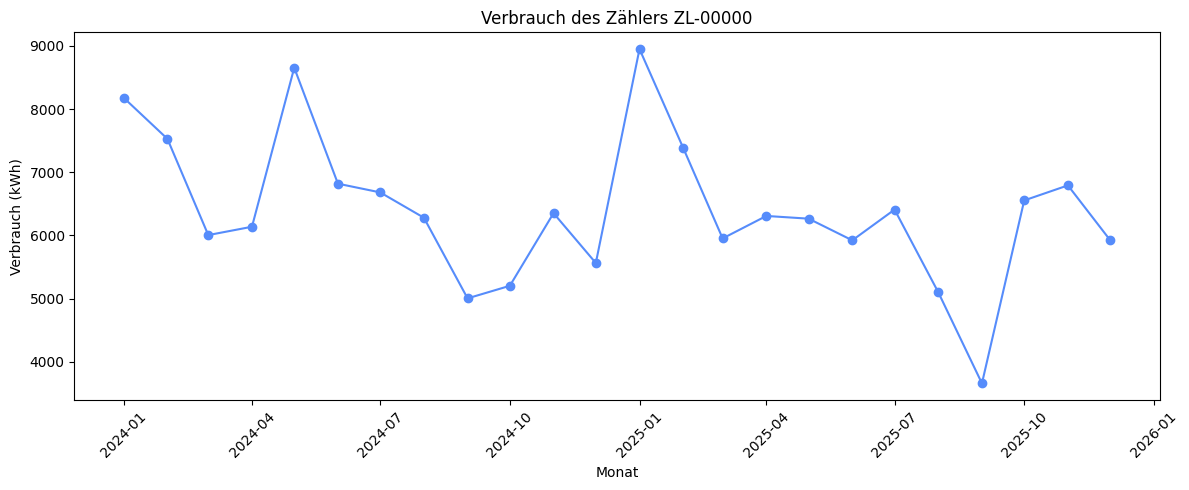

In [153]:
zaehler = outliers_zaehler["zaehler_id"].iloc[0]

df_z = (
    df[df["zaehler_id"] == zaehler]
    .sort_values("monat")
)

plt.figure(figsize=(12, 5))
plt.plot(
    df_z["monat"],
    df_z["verbrauch_kwh"],
    marker="o"
)

plt.xlabel("Monat")
plt.ylabel("Verbrauch (kWh)")
plt.title(f"Verbrauch des Zählers {zaehler}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [154]:
top10 = outliers_zaehler.sort_values(
    "abweichung",
    ascending=False
).head(10)

print(
    top10[
        [
            "zaehler_id",
            "monat",
            "kundentyp",
            "verbrauch_kwh",
            "untere_grenze",
            "obere_grenze",
            "abweichung"
        ]
    ]
)

      zaehler_id      monat  kundentyp  verbrauch_kwh  untere_grenze  \
10972   ZL-00457 2024-05-01  Industrie  675230.570286      79954.625   
15025   ZL-00626 2024-02-01  Industrie  327479.783013      67333.625   
1641    ZL-00068 2024-10-01  Industrie  381300.240647      40551.125   
5480    ZL-00228 2024-09-01  Industrie  328824.021898      43766.250   
8415    ZL-00350 2025-04-01  Industrie  273834.387063      20776.250   
3633    ZL-00151 2024-10-01  Industrie  353195.939270      64612.625   
1635    ZL-00068 2024-04-01  Industrie  345599.634369      40551.125   
15027   ZL-00626 2024-04-01  Industrie  278941.698084      67333.625   
5649    ZL-00235 2024-10-01  Industrie  211642.226455      19128.125   
4140    ZL-00172 2025-01-01  Industrie  232652.000000      27509.500   

       obere_grenze     abweichung  
10972    302851.625  372378.945286  
15025    119692.625  207787.158013  
1641     182976.125  198324.115647  
5480     151766.250  177057.771898  
8415     101172.250  1

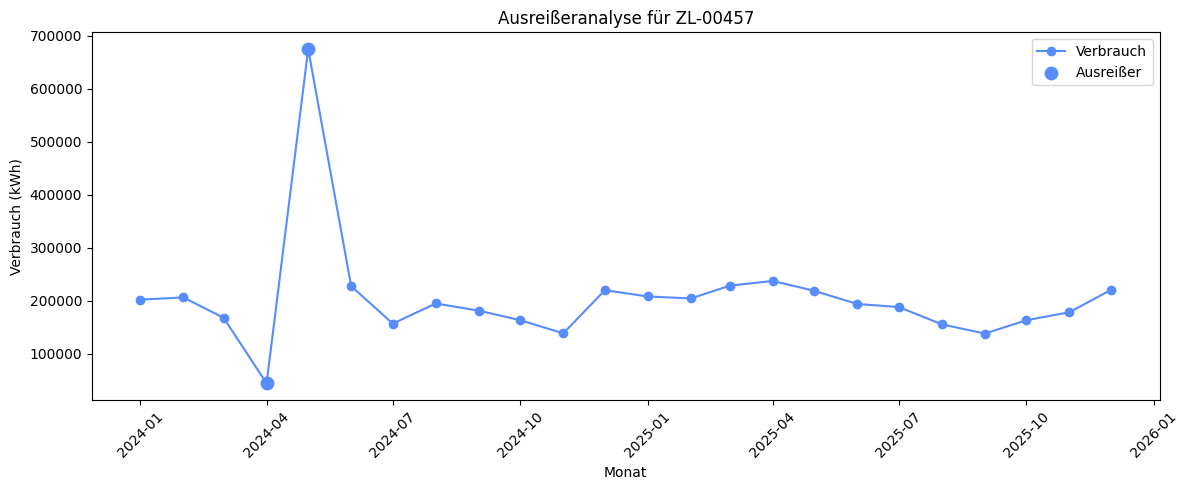

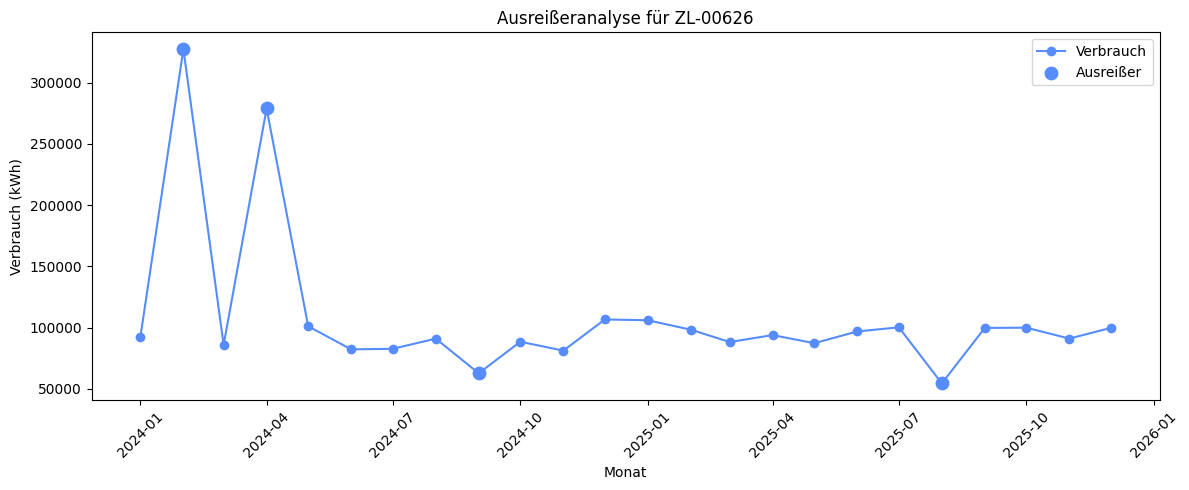

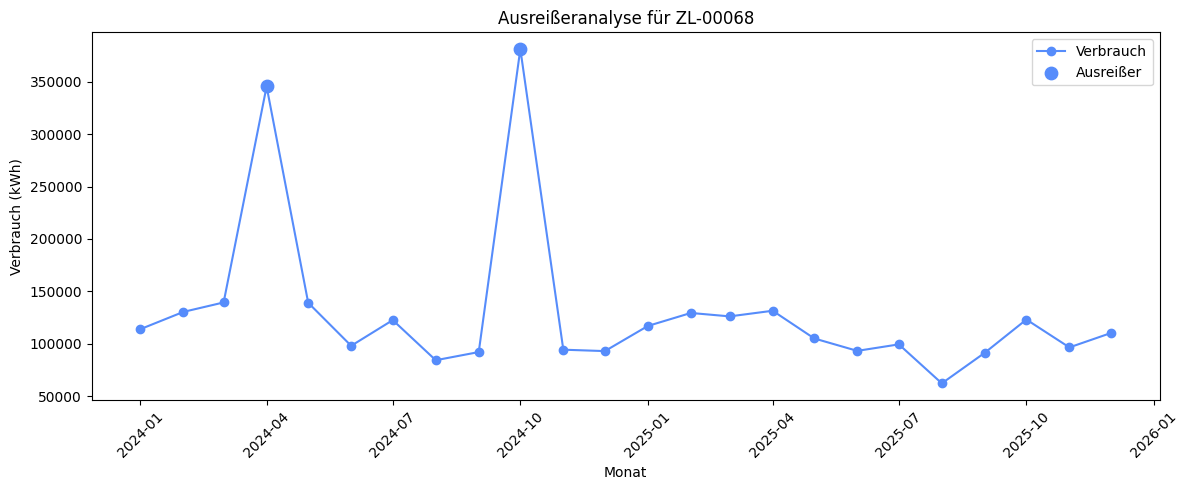

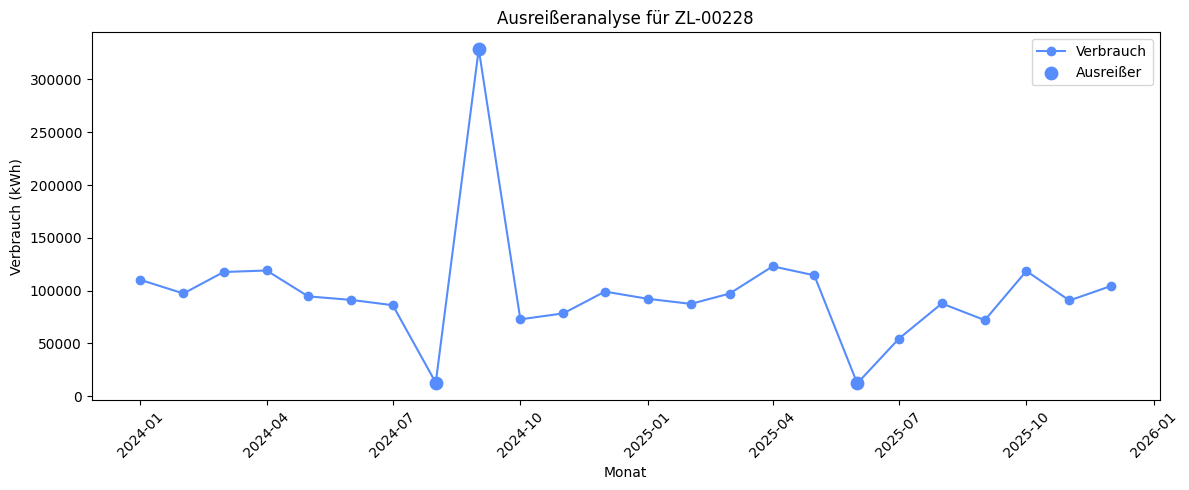

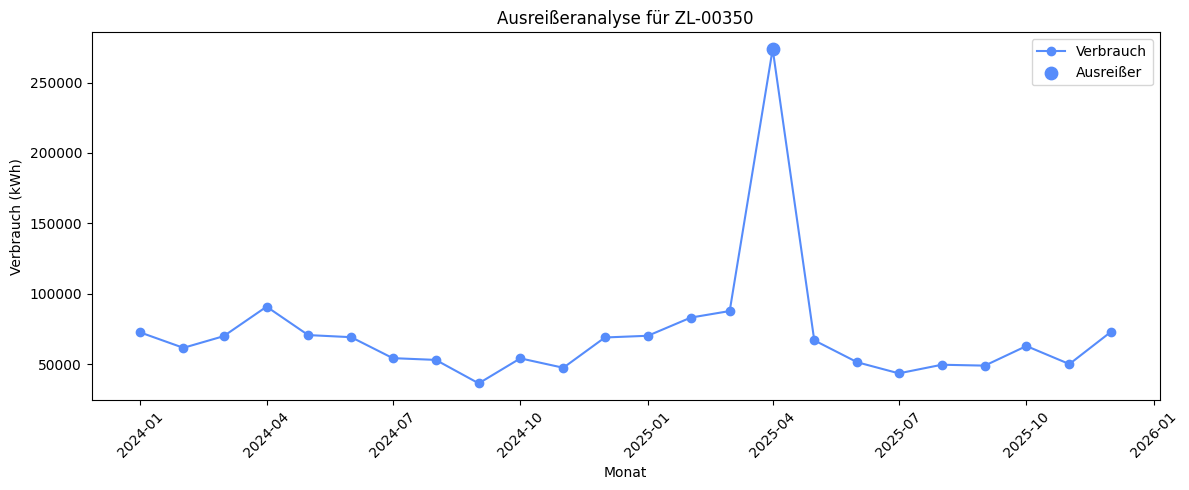

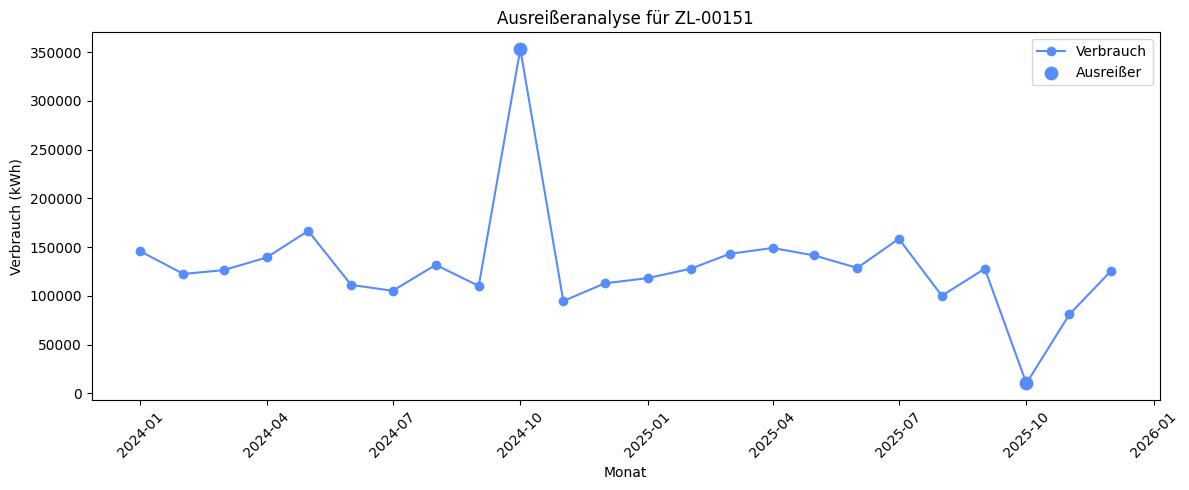

In [155]:
zaehler_liste = top10["zaehler_id"].head(6).tolist()

for zaehler in zaehler_liste:
    df_z = (
        df[df["zaehler_id"] == zaehler]
        .sort_values("monat")
    )

    out_z = outliers_zaehler[
        outliers_zaehler["zaehler_id"] == zaehler
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        df_z["monat"],
        df_z["verbrauch_kwh"],
        marker="o",
        label="Verbrauch"
    )

    plt.scatter(
        out_z["monat"],
        out_z["verbrauch_kwh"],
        s=80,
        label="Ausreißer"
    )

    plt.xlabel("Monat")
    plt.ylabel("Verbrauch (kWh)")
    plt.title(f"Ausreißeranalyse für {zaehler}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 14.1.3 Technische Plausibilitätsprüfung Auslastung über 100 %:

In [156]:
print(df["monat"].dtype)

datetime64[ns]


In [157]:
df["monat"] = pd.to_datetime(df["monat"])

In [158]:
import calendar

# die Anzahl der Stunden im jeweiligen Monat
df["stunden_im_monat"] = df["monat"].dt.days_in_month * 24

# der theoretisch maximale Verbrauch bei durchgehendem Betrieb
df["max_verbrauch_kwh"] = (
    df["vertragsleistung_kw"] * df["stunden_im_monat"]
)

# der Anteil des tatsächlichen Verbrauchs am theoretischen Maximum
df["auslastung_prozent"] = (
    df["verbrauch_kwh"] / df["max_verbrauch_kwh"] * 100
)

# die Überschreitung des theoretischen Maximums
df["verbrauch_ueber_vertragsleistung"] = (
    df["verbrauch_kwh"] > df["max_verbrauch_kwh"]
)

print(
    df[
        [
            "zaehler_id",
            "monat",
            "vertragsleistung_kw",
            "verbrauch_kwh",
            "max_verbrauch_kwh",
            "auslastung_prozent",
            "verbrauch_ueber_vertragsleistung"
        ]
    ].head()
)

  zaehler_id      monat  vertragsleistung_kw  verbrauch_kwh  \
0   ZL-00000 2024-01-01                   74         8179.0   
1   ZL-00000 2024-02-01                   74         7529.0   
2   ZL-00000 2024-03-01                   74         6005.0   
3   ZL-00000 2024-04-01                   74         6137.0   
4   ZL-00000 2024-05-01                   74         8655.0   

   max_verbrauch_kwh  auslastung_prozent  verbrauch_ueber_vertragsleistung  
0              55056           14.855783                             False  
1              51504           14.618282                             False  
2              55056           10.907076                             False  
3              53280           11.518393                             False  
4              55056           15.720357                             False  


In [159]:
plausibility_issues = df[
    df["verbrauch_ueber_vertragsleistung"]
].copy()

print("Anzahl:", len(plausibility_issues))

print(
    plausibility_issues[
        [
            "zaehler_id",
            "monat",
            "kundentyp",
            "vertragsleistung_kw",
            "verbrauch_kwh",
            "max_verbrauch_kwh",
            "auslastung_prozent"
        ]
    ]
    .sort_values("auslastung_prozent", ascending=False)
)

Anzahl: 20
      zaehler_id      monat  kundentyp  vertragsleistung_kw  verbrauch_kwh  \
7383    ZL-00307 2025-04-01    Gewerbe                   59   61629.313469   
14845   ZL-00618 2025-02-01    Gewerbe                  105   99823.952707   
12196   ZL-00508 2024-05-01  Industrie                  184  190085.763368   
15385   ZL-00641 2024-02-01    Gewerbe                  100   90101.483384   
5649    ZL-00235 2024-10-01  Industrie                  225  211642.226455   
5939    ZL-00247 2024-12-01  Industrie                   71   64318.581332   
2033    ZL-00084 2025-06-01   Kommunal                   35   28447.366167   
819     ZL-00034 2024-04-01   Kommunal                   65   52756.000000   
15025   ZL-00626 2024-02-01  Industrie                  424  327479.783013   
11244   ZL-00468 2025-01-01   Kommunal                   73   59099.791812   
14617   ZL-00609 2024-02-01  Industrie                  100   75540.108976   
8415    ZL-00350 2025-04-01  Industrie               

In [160]:
suspicious = df[
    df["verbrauch_ueber_vertragsleistung"]
].copy()

for zaehler, monat in zip(
    suspicious["zaehler_id"],
    suspicious["monat"]
):

    df_z = (
        df[df["zaehler_id"] == zaehler]
        .sort_values("monat")
        .copy()
    )

    # Kennzeichnung des auffälligen Monats
    df_z["auffaellig"] = ""

    df_z.loc[
        df_z["monat"] == monat,
        "auffaellig"
    ] = "← VERBRAUCH ÜBER VERTRAGSLEISTUNG"

    print("\n" + "=" * 80)
    print(
        f"Zähler: {zaehler} | "
        f"auffälliger Monat: {monat.strftime('%Y-%m')}"
    )

    print(
        df_z[
            [
                "monat",
                "verbrauch_kwh",
                "vormonat_verbrauch_kwh",
                "vertragsleistung_kw",
                "verbrauch_ueber_vertragsleistung",
                "auffaellig"
            ]
        ].to_string(index=False)
    )


Zähler: ZL-00034 | auffälliger Monat: 2024-04
     monat  verbrauch_kwh  vormonat_verbrauch_kwh  vertragsleistung_kw  verbrauch_ueber_vertragsleistung                        auffaellig
2024-01-01   17747.000000                     NaN                   65                             False                                  
2024-02-01   18746.000000            17747.000000                   65                             False                                  
2024-03-01   17470.000000            18746.000000                   65                             False                                  
2024-04-01   52756.000000            17470.000000                   65                              True ← VERBRAUCH ÜBER VERTRAGSLEISTUNG
2024-05-01   15433.000000            52755.508767                   65                             False                                  
2024-06-01   10748.000000            15433.000000                   65                             False               

In [161]:
suspicious["abweichung_vormonat_prozent"] = (
    (suspicious["verbrauch_kwh"] -
     suspicious["vormonat_verbrauch_kwh"])
    / suspicious["vormonat_verbrauch_kwh"] * 100
)

print(
    suspicious[
        [
            "zaehler_id",
            "monat",
            "verbrauch_kwh",
            "vormonat_verbrauch_kwh",
            "abweichung_vormonat_prozent",
            "auslastung_prozent"
        ]
    ].sort_values(
        "abweichung_vormonat_prozent",
        ascending=False
    )
)

      zaehler_id      monat  verbrauch_kwh  vormonat_verbrauch_kwh  \
5649    ZL-00235 2024-10-01  211642.226455                 30563.0   
8111    ZL-00337 2025-12-01  123244.468718                 24249.0   
6618    ZL-00275 2025-07-01   39348.709685                  8238.0   
2033    ZL-00084 2025-06-01   28447.366167                  6128.0   
12196   ZL-00508 2024-05-01  190085.763368                 42878.0   
11244   ZL-00468 2025-01-01   59099.791812                 13537.0   
4140    ZL-00172 2025-01-01  232652.000000                 54174.0   
14845   ZL-00618 2025-02-01   99823.952707                 24127.0   
13642   ZL-00568 2024-11-01   65189.034921                 17761.0   
13801   ZL-00575 2024-02-01   63172.013304                 17356.0   
5939    ZL-00247 2024-12-01   64318.581332                 17682.0   
15025   ZL-00626 2024-02-01  327479.783013                 92731.0   
9434    ZL-00393 2024-03-01   22068.901026                  6511.0   
7383    ZL-00307 202

In [162]:
suspicious = suspicious.copy()

suspicious["abweichung_vormonat_prozent"] = (
    (suspicious["verbrauch_kwh"] -
     suspicious["vormonat_verbrauch_kwh"])
    / suspicious["vormonat_verbrauch_kwh"] * 100
)

print(
    suspicious[
        [
            "zaehler_id",
            "monat",
            "verbrauch_kwh",
            "vormonat_verbrauch_kwh",
            "abweichung_vormonat_prozent",
            "auslastung_prozent",
            "verbrauch_ueber_vertragsleistung"
        ]
    ].sort_values(
        "abweichung_vormonat_prozent",
        ascending=False
    ).to_string(index=False)
)

zaehler_id      monat  verbrauch_kwh  vormonat_verbrauch_kwh  abweichung_vormonat_prozent  auslastung_prozent  verbrauch_ueber_vertragsleistung
  ZL-00235 2024-10-01  211642.226455                 30563.0                   592.478574          126.429048                              True
  ZL-00337 2025-12-01  123244.468718                 24249.0                   408.245572          106.186646                              True
  ZL-00275 2025-07-01   39348.709685                  8238.0                   377.648819          103.702060                              True
  ZL-00084 2025-06-01   28447.366167                  6128.0                   364.219422          112.886374                              True
  ZL-00508 2024-05-01  190085.763368                 42878.0                   343.317700          138.854140                              True
  ZL-00468 2025-01-01   59099.791812                 13537.0                   336.579684          108.815348                           

In [163]:
technisch_auffaellig = df[
    df["verbrauch_ueber_vertragsleistung"]
].copy()

print(
    technisch_auffaellig["monat"]
    .dt.year
    .value_counts()
    .sort_index()
)

monat
2024    10
2025    10
Name: count, dtype: int64


In [164]:
technisch_auffaellig = df[
    df["verbrauch_ueber_vertragsleistung"]
].copy()

technisch_auffaellig["jahr"] = technisch_auffaellig["monat"].dt.year

auffaellig_2024 = technisch_auffaellig[
    technisch_auffaellig["jahr"] == 2024
]

auffaellig_2025 = technisch_auffaellig[
    technisch_auffaellig["jahr"] == 2025
]

print("2024:", len(auffaellig_2024))
print("2025:", len(auffaellig_2025))

2024: 10
2025: 10


In [165]:
print("2024:")
print(auffaellig_2024["kundentyp"].value_counts())

print("\n2025:")
print(auffaellig_2025["kundentyp"].value_counts())

2024:
kundentyp
Industrie    5
Gewerbe      3
Kommunal     2
Name: count, dtype: int64

2025:
kundentyp
Kommunal     4
Gewerbe      3
Industrie    3
Name: count, dtype: int64


Die technisch auffälligen Verbrauchswerte zeigen sowohl 2024 als auch 2025 ein ähnliches Muster. In beiden Jahren treten hohe relative Abweichungen gegenüber dem Vormonat sowie eine vergleichbare Überschreitung der theoretischen Auslastung auf. Gleichzeitig liegt der Produktionsplanindex im Mittel über dem Basiswert von 1. Die Auffälligkeiten können daher teilweise mit einer erhöhten betrieblichen Aktivität zusammenhängen. Ein eindeutiger Datenfehler lässt sich aus diesen Merkmalen jedoch nicht ableiten.

In [166]:
print(
    "Verschiedene Zähler:",
    technisch_auffaellig["zaehler_id"].nunique()
)

print(
    "Verschiedene Monate_Jahr:",
    technisch_auffaellig["monat"].dt.to_period("M").nunique()
)

Verschiedene Zähler: 20
Verschiedene Monate_Jahr: 14


In [167]:
print(
    "Verschiedene Monate_idx:",
    technisch_auffaellig["monat_idx"].nunique()
)

Verschiedene Monate_idx: 10


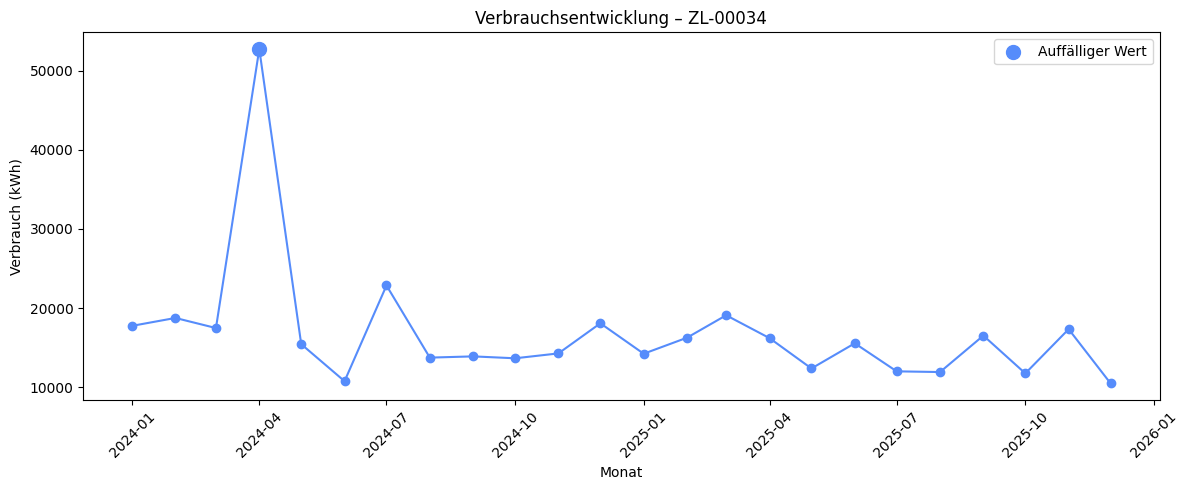

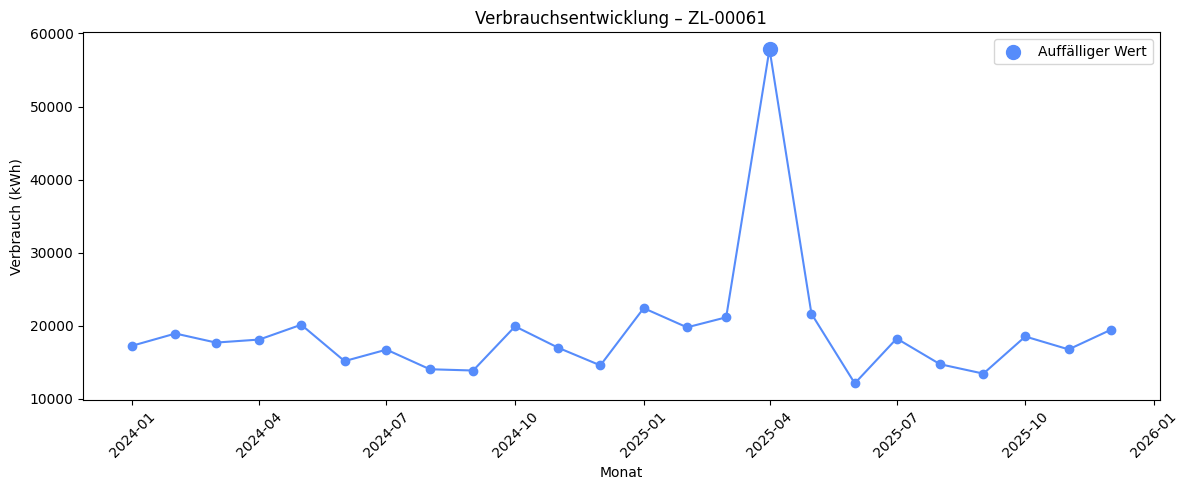

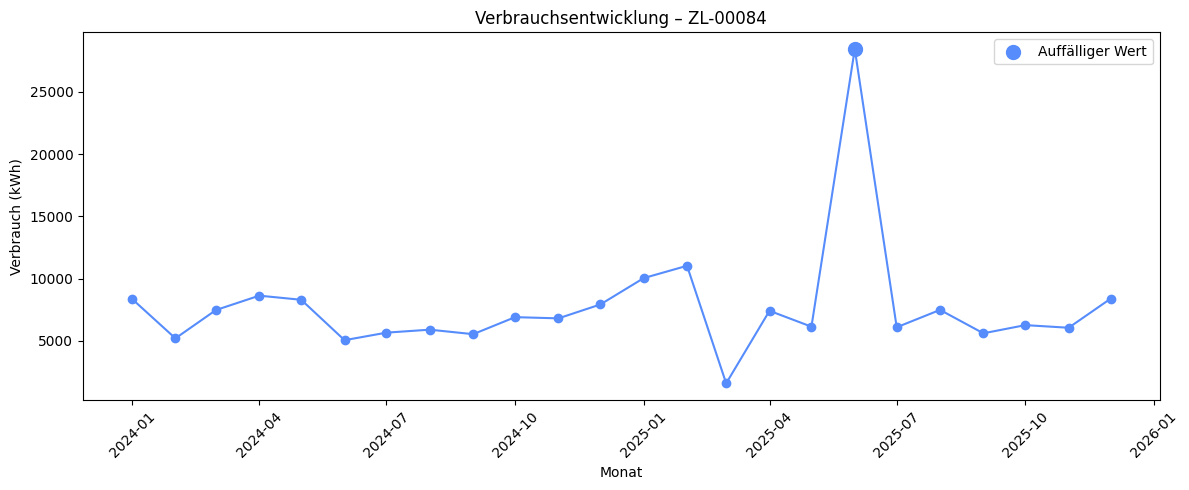

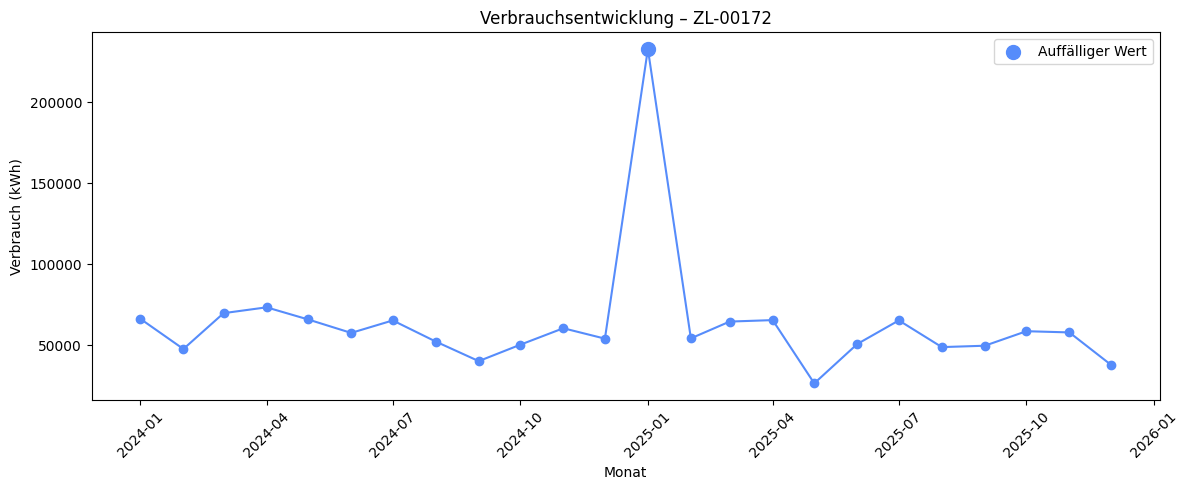

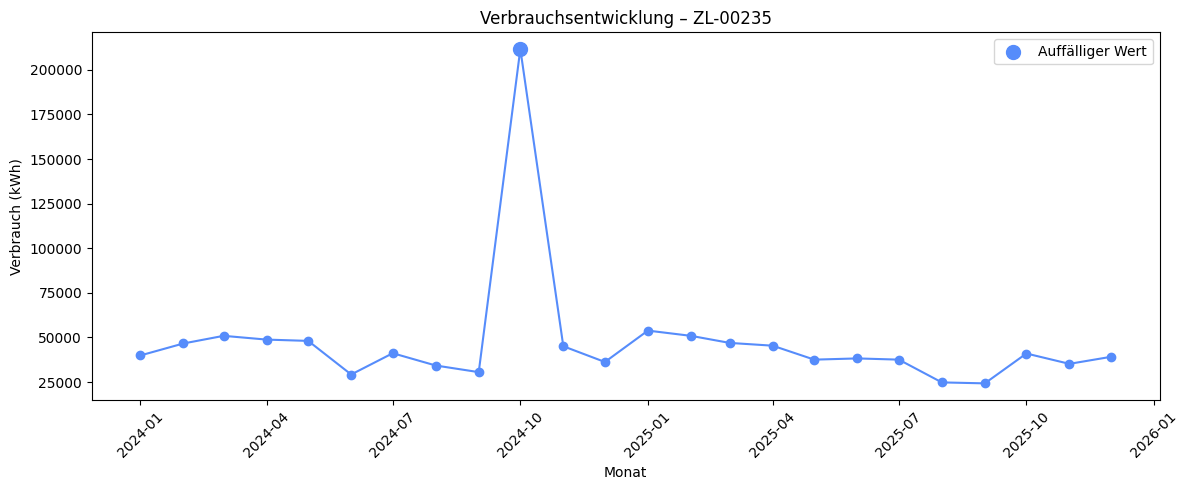

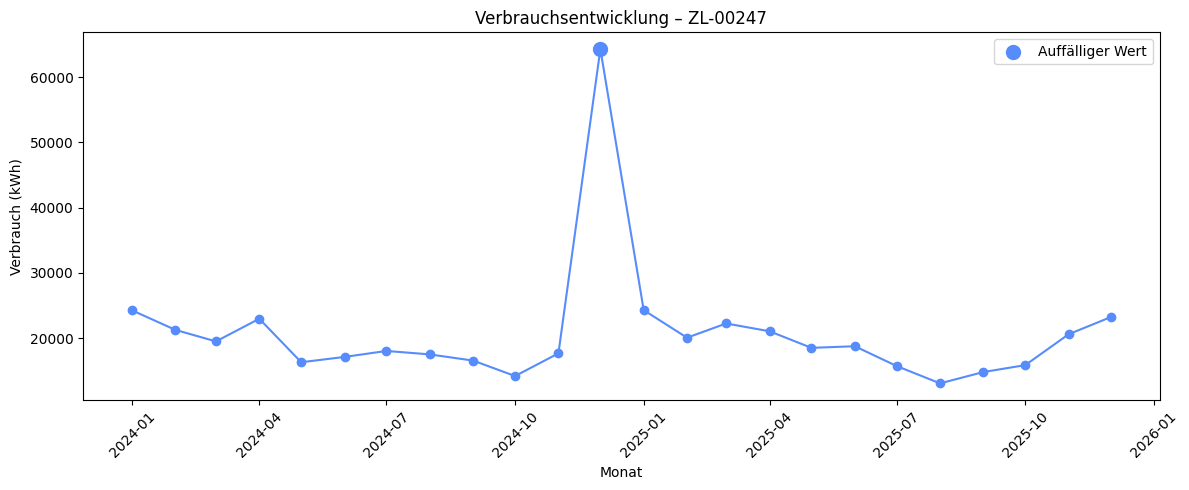

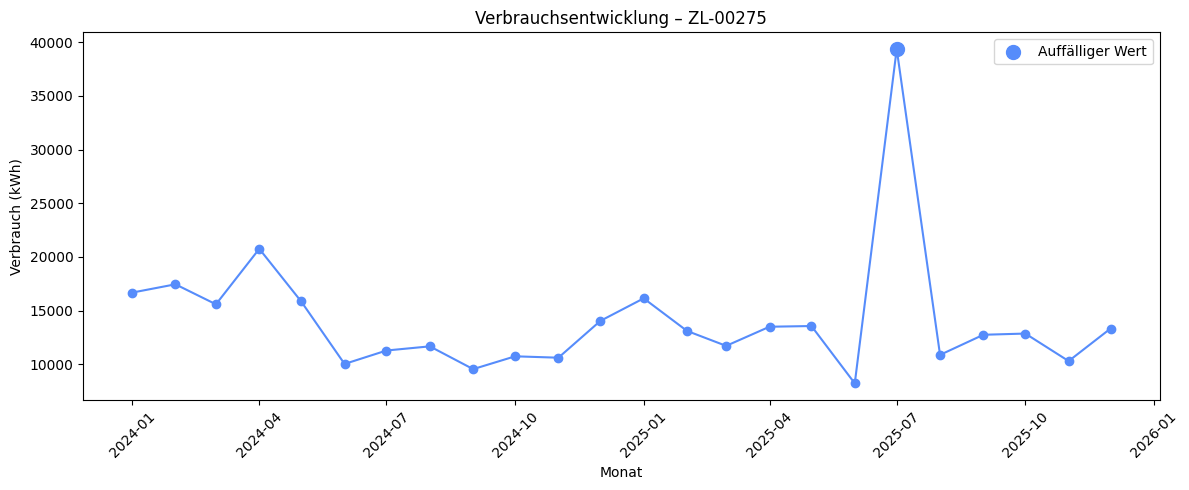

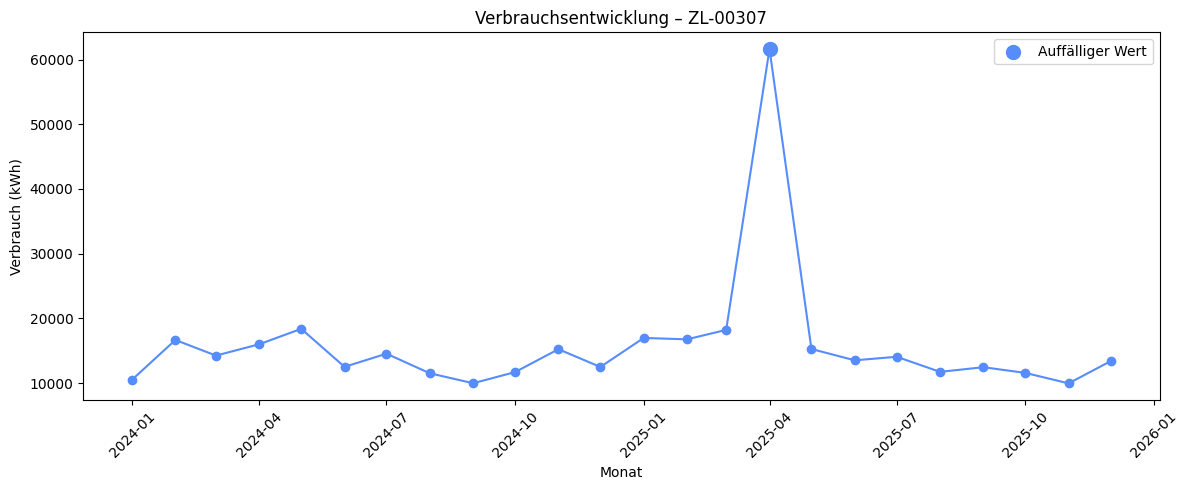

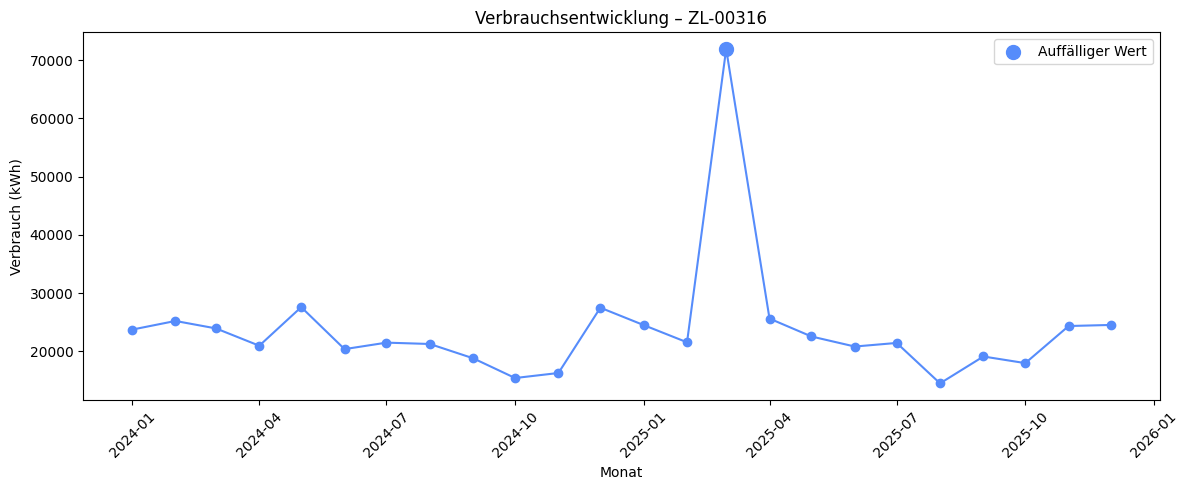

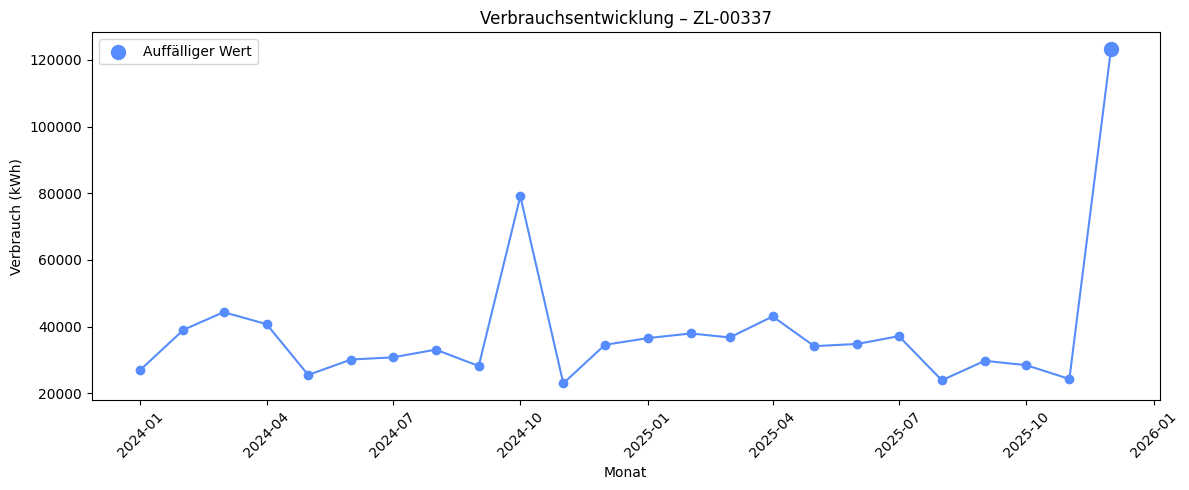

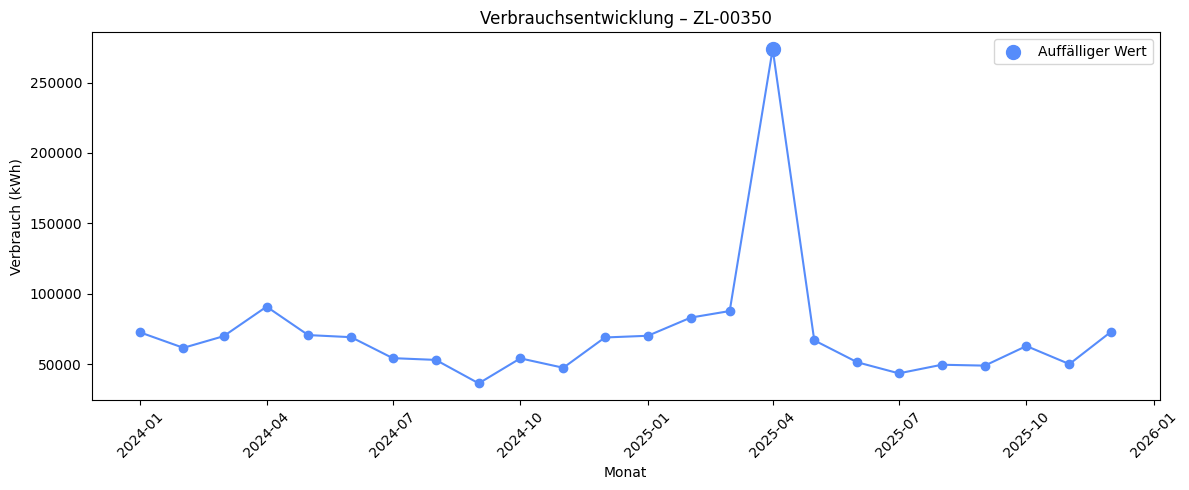

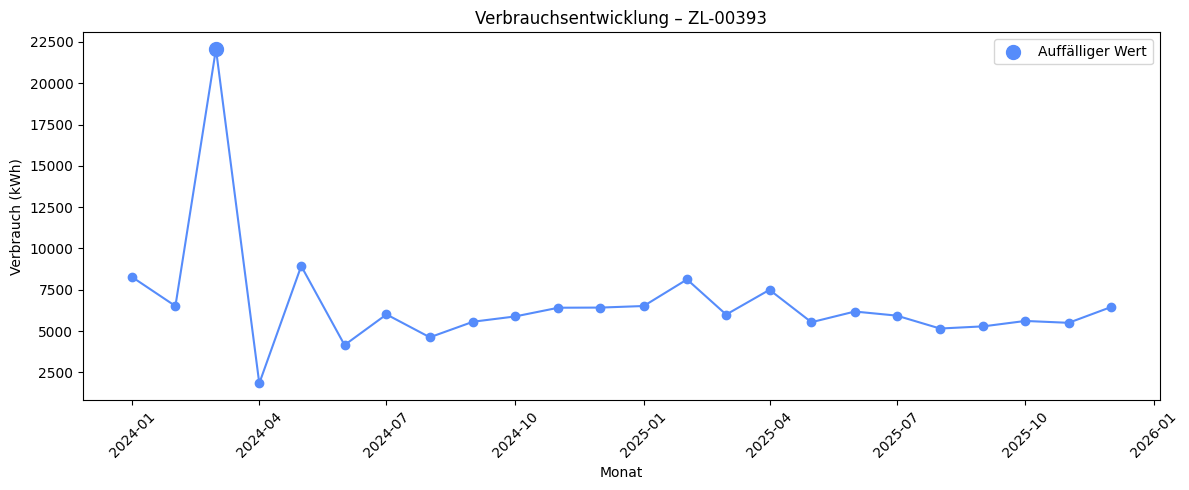

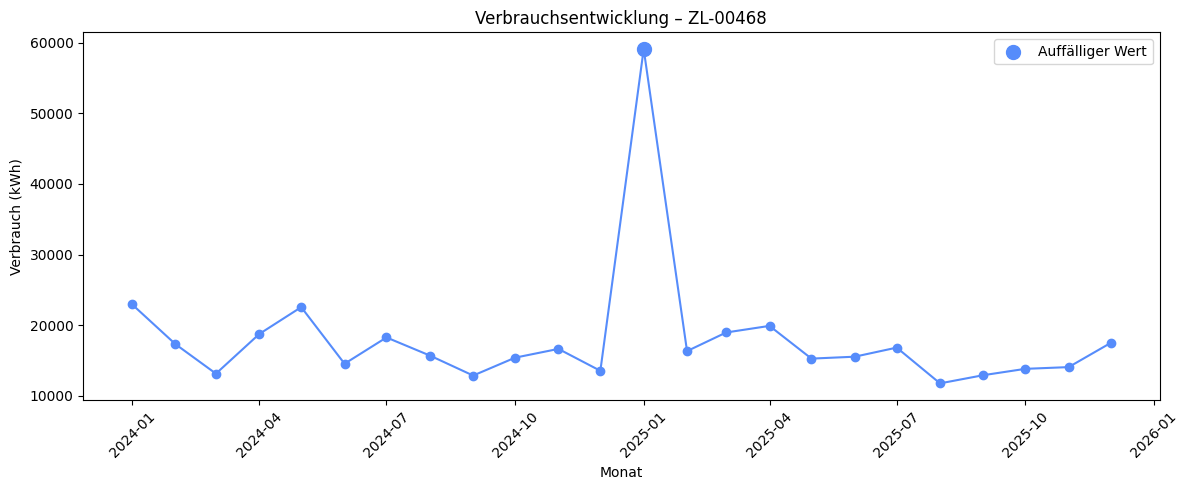

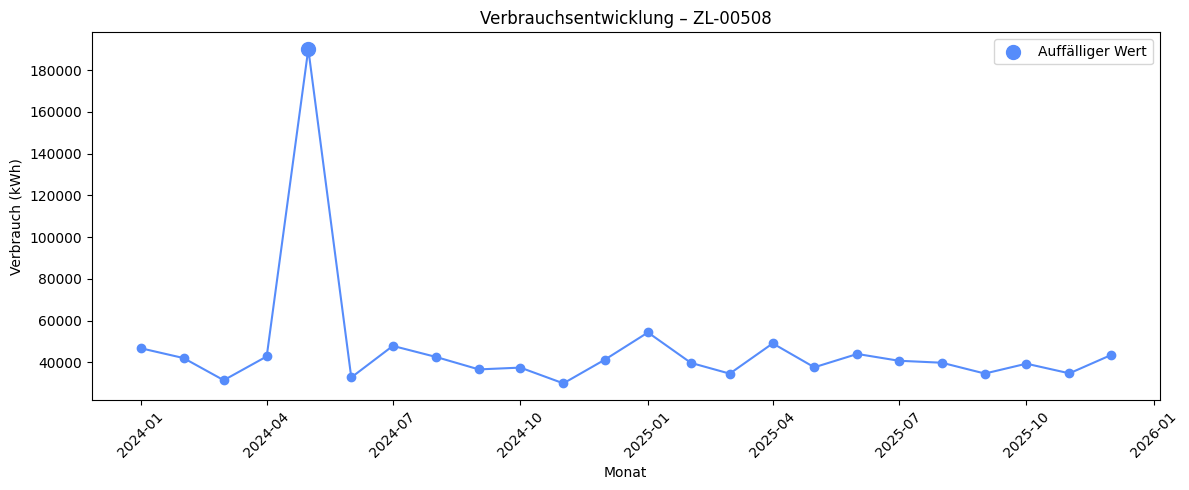

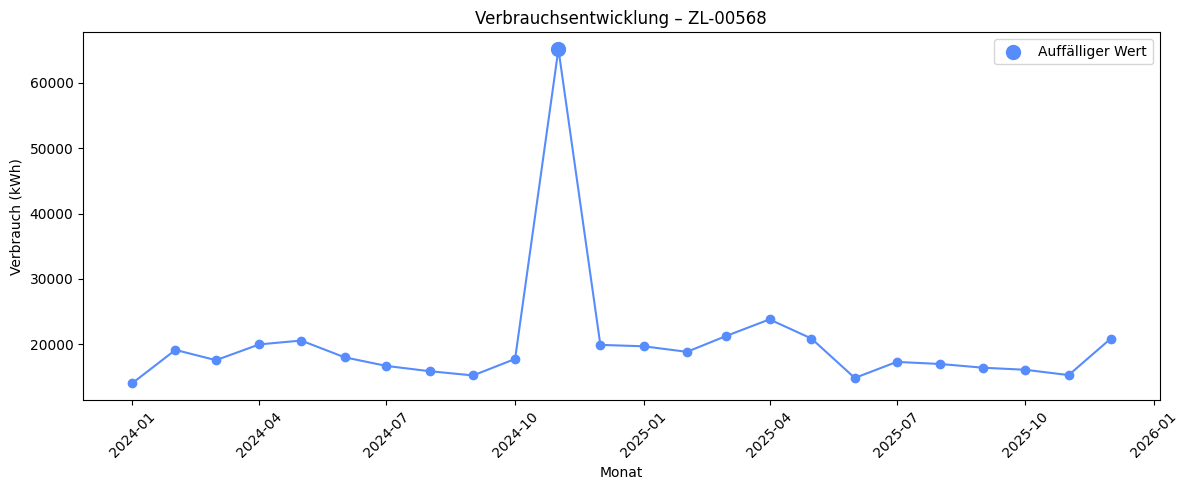

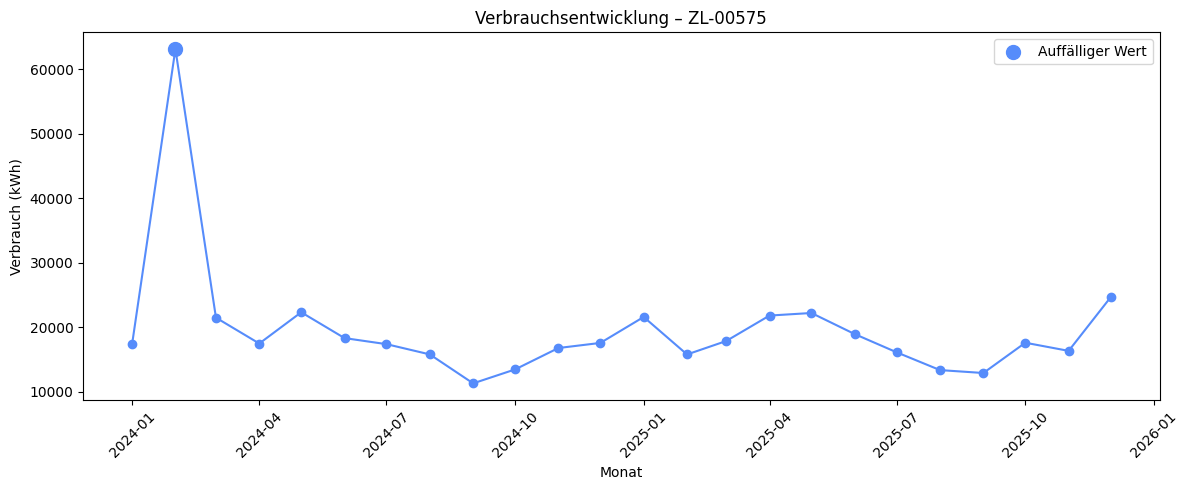

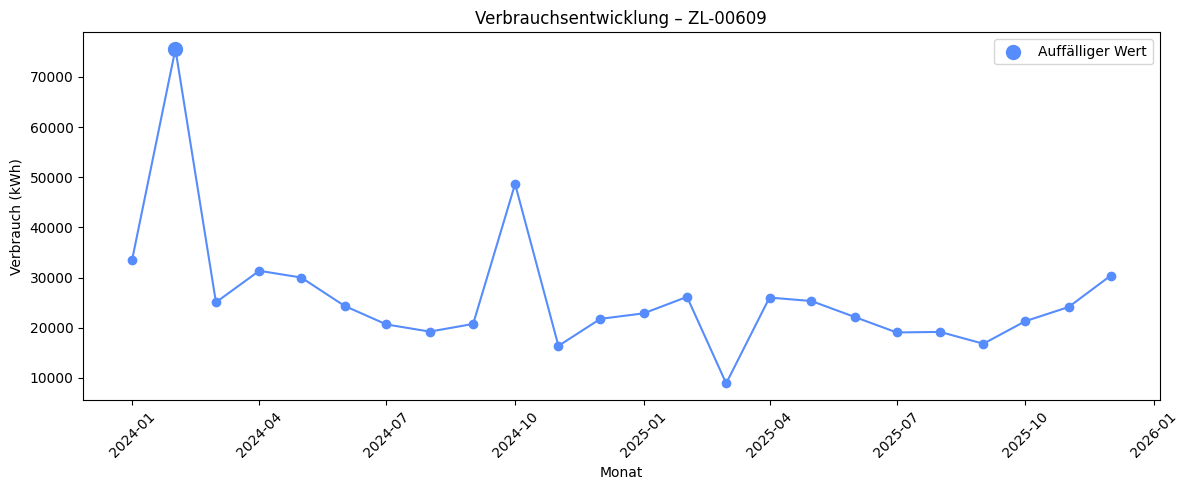

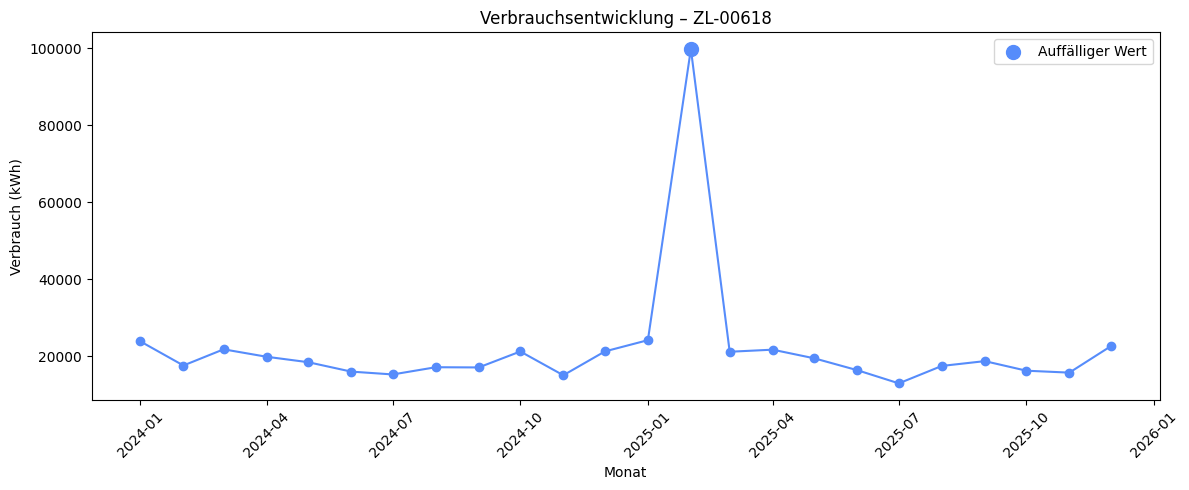

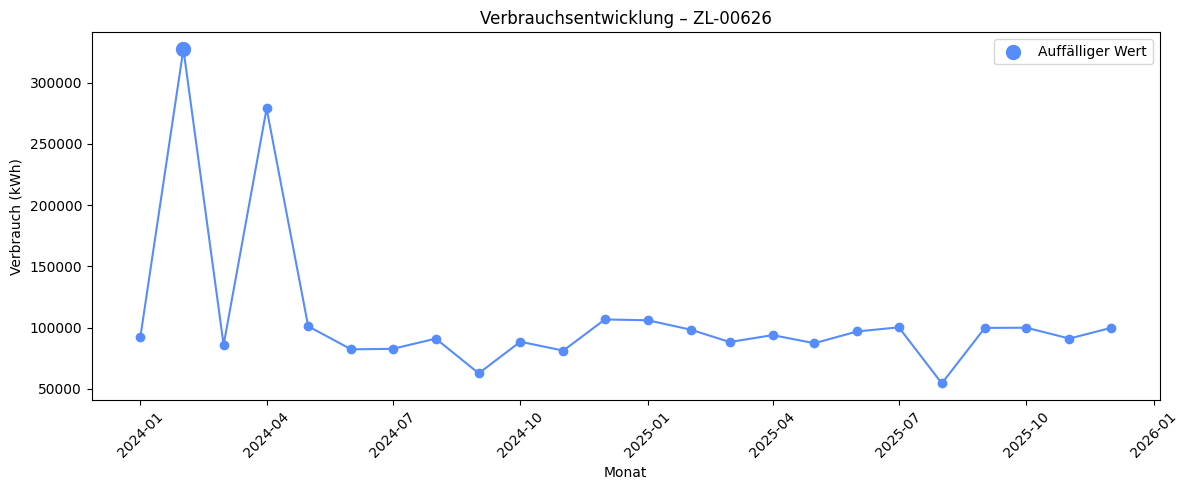

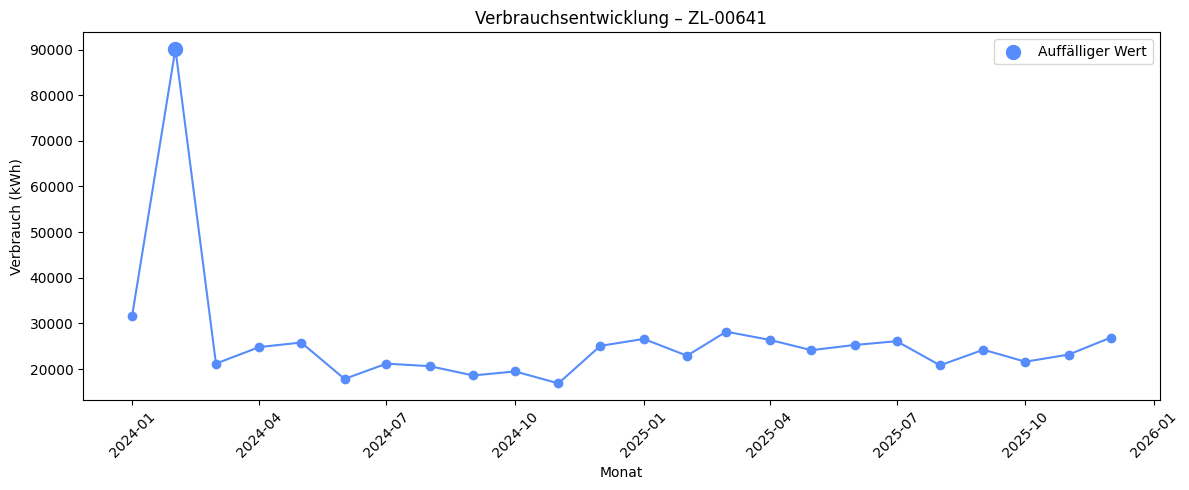

In [168]:
for zaehler in suspicious["zaehler_id"]:

    df_z = (
        df[df["zaehler_id"] == zaehler]
        .sort_values("monat")
    )

    out_z = suspicious[
        suspicious["zaehler_id"] == zaehler
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        df_z["monat"],
        df_z["verbrauch_kwh"],
        marker="o"
    )

    plt.scatter(
        out_z["monat"],
        out_z["verbrauch_kwh"],
        s=100,
        label="Auffälliger Wert"
    )

    plt.xlabel("Monat")
    plt.ylabel("Verbrauch (kWh)")
    plt.title(f"Verbrauchsentwicklung – {zaehler}")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 14.1.4 Technische Plausibilitätsprüfung:Auslastung < 1 %

In [169]:
min_auffaellig_auslastung = df[df["auslastung_prozent"] < 1]
print("Anzahl min auffälliger Werte:", len(min_auffaellig_auslastung))

Anzahl min auffälliger Werte: 5


In [170]:
niedrige_auslastung = df[df["auslastung_prozent"] < 1]

print(
    niedrige_auslastung[
        [
            "zaehler_id",
            "monat",
            "kundentyp",
            "wartung_aktiv",
            "verbrauch_kwh",
            "vertragsleistung_kw",
            "auslastung_prozent",
            "feiertage_im_monat"
        ]
    ]
)

      zaehler_id      monat  kundentyp  wartung_aktiv  verbrauch_kwh  \
219     ZL-00009 2024-04-01    Gewerbe              0     418.444993   
605     ZL-00025 2024-06-01  Industrie              0    2569.516630   
7025    ZL-00292 2025-06-01  Industrie              0    2856.105548   
9374    ZL-00390 2025-03-01    Gewerbe              1     147.815378   
14781   ZL-00615 2025-10-01    Gewerbe              0     401.978642   

       vertragsleistung_kw  auslastung_prozent  feiertage_im_monat  
219                     76            0.764702                   1  
605                    409            0.872561                   0  
7025                   439            0.903602                   0  
9374                    24            0.827819                   0  
14781                   60            0.900490                   1  


Bei der Prüfung der Auslastung wurden fünf Beobachtungen mit einer Auslastung von unter 1 % identifiziert. Die Fälle weisen teilweise sehr geringe monatliche Verbräuche im Verhältnis zur vertraglichen Leistung auf. Ein eindeutiger Datenfehler ist jedoch nicht erkennbar. Bei einer Beobachtung ist zudem eine aktive Wartung vermerkt, wodurch der geringe Verbrauch plausibel erklärt werden kann. Die übrigen Fälle können beispielsweise durch einen zeitweise geringen Betriebsumfang oder eine geringe tatsächliche Nutzung verursacht sein. Daher wurden die fünf Beobachtungen nicht entfernt, sondern als auffällige, aber grundsätzlich plausible Fälle dokumentiert.

In [171]:
# 530 statistische Ausreißer
stat_outliers = outliers_zaehler.index

# 20 technische Auffälligkeiten
tech_outliers = df[df["verbrauch_ueber_vertragsleistung"]].index

# Überschneidung
intersection = stat_outliers.intersection(tech_outliers)

print("Statistische Ausreißer:", len(stat_outliers))
print("Technisch auffällig:", len(tech_outliers))
print("Beide Kriterien:", len(intersection))

Statistische Ausreißer: 529
Technisch auffällig: 20
Beide Kriterien: 20


## 14.2 starke Veränderung gegenüber dem Vormonat


In [172]:
df["abweichung_vormonat_prozent"] = (
    (df["verbrauch_kwh"] - df["vormonat_verbrauch_kwh"])
    / df["vormonat_verbrauch_kwh"] * 100
)

print(df["abweichung_vormonat_prozent"])

0              NaN
1        -7.947182
2       -20.241732
3         2.198168
4        41.029819
           ...    
16795   -11.405708
16796    23.909022
16797    -3.152995
16798   -11.834588
16799    76.445176
Name: abweichung_vormonat_prozent, Length: 16800, dtype: float64


In [173]:
starke_aenderung = df[
    df["abweichung_vormonat_prozent"].abs() > 100
]

print("Anzahl:", len(starke_aenderung))

Anzahl: 340


In [174]:
starker_anstieg = df[
    df["abweichung_vormonat_prozent"] > 100
]

starker_rueckgang = df[
    df["abweichung_vormonat_prozent"] < -100
]

print("Starker Anstieg:", len(starker_anstieg))
print("Starker Rückgang:", len(starker_rueckgang))

Starker Anstieg: 340
Starker Rückgang: 0


In [175]:
starke_aenderung_50 = df[
    df["abweichung_vormonat_prozent"].abs() > 50
]

print("Abweichung > ±50 %:", len(starke_aenderung_50))

Abweichung > ±50 %: 1341


In [176]:
print(
    "Anstieg > 50 %:",
    (df["abweichung_vormonat_prozent"] > 50).sum()
)

print(
    "Rückgang < -50 %:",
    (df["abweichung_vormonat_prozent"] < -50).sum()
)

Anstieg > 50 %: 986
Rückgang < -50 %: 355


In [177]:
id="x2k7pa"
stat_outlier_idx = outliers_zaehler.index

starke_aenderung_idx = df[
    df["abweichung_vormonat_prozent"].abs() > 50
].index

print(
    "IQR-Ausreißer:",
    len(stat_outlier_idx)
)

print(
    "Starke Änderung:",
    len(starke_aenderung_idx)
)

print(
    "Beide Kriterien:",
    len(stat_outlier_idx.intersection(starke_aenderung_idx))
)

IQR-Ausreißer: 529
Starke Änderung: 1341
Beide Kriterien: 370


## 14.3 Verbrauch gegenüber 3-Monats-Durchschnitt

In [178]:
df["abweichung_3m_prozent"] = (
    (df["verbrauch_kwh"] - df["letzte_3_monate_durchschnitt_kwh"])
    / df["letzte_3_monate_durchschnitt_kwh"] * 100
)
print(df["abweichung_3m_prozent"])

0              NaN
1        -7.947182
2       -23.542144
3       -15.207479
4        31.996340
           ...    
16795   -21.313581
16796    11.532685
16797     6.895660
16798    -7.708373
16799    60.143146
Name: abweichung_3m_prozent, Length: 16800, dtype: float64


In [179]:
auffaellig_3m = df[
    df["abweichung_3m_prozent"].abs() > 100
]

print("Anzahl:", len(auffaellig_3m))

Anzahl: 445


In [180]:
auffaellig_3m = df[
    df["abweichung_3m_prozent"].abs() > 100
]

print("Anzahl:", len(auffaellig_3m))

Anzahl: 445


In [181]:
auffaellig_3m = df[
    df["abweichung_3m_prozent"].abs() > 100
].copy()

print(
    auffaellig_3m[
        [
            "zaehler_id",
            "monat",
            "verbrauch_kwh",
            "letzte_3_monate_durchschnitt_kwh",
            "vormonat_verbrauch_kwh",
            "vertragsleistung_kw",
            "produktionsplan_index",
            "mittlere_temperatur_c",
            "heiztage"
        ]
    ]
)

      zaehler_id      monat  verbrauch_kwh  letzte_3_monate_durchschnitt_kwh  \
24      ZL-00001 2024-01-01   24075.000000                       6673.000000   
96      ZL-00004 2024-01-01   17419.000000                       2243.000000   
120     ZL-00005 2024-01-01   83819.000000                      14927.000000   
192     ZL-00008 2024-01-01   86704.000000                      12326.000000   
264     ZL-00011 2024-01-01   14921.000000                       4561.500000   
...          ...        ...            ...                               ...   
16656   ZL-00694 2024-01-01   32989.000000                       2234.000000   
16657   ZL-00694 2024-02-01   41609.000000                      17710.000000   
16680   ZL-00695 2024-01-01   58795.000000                      21446.000000   
16776   ZL-00699 2024-01-01   13520.000000                       4357.000000   
16787   ZL-00699 2024-12-01   38830.123186                      11755.333333   

       vormonat_verbrauch_kwh  vertrags

## 14.4 produktionsplan_index


In [182]:
print(df["produktionsplan_index"].describe())

count    16128.000000
mean         1.000244
std          0.132855
min          0.579000
25%          0.899000
50%          1.000000
75%          1.100000
max          1.406000
Name: produktionsplan_index, dtype: float64


In [183]:
produktionsplan_auffaellig = df[
    (df["produktionsplan_index"] < 0.7) |
    (df["produktionsplan_index"] > 1.3)
]
print("Anzahl auffälliger Werte:", len(produktionsplan_auffaellig))

Anzahl auffälliger Werte: 188


Der Produktionsplanindex weist insgesamt eine plausible Verteilung um den Basiswert 1,0 auf. Der Mittelwert liegt bei 1,0002 und der Median bei 1,0. Insgesamt wurden 188 statistisch auffällige Werte identifiziert. Diese Werte stellen jedoch nicht zwangsläufig Datenfehler dar, da starke Abweichungen des geplanten Produktionsniveaus betriebswirtschaftlich plausibel sein können. Sie werden daher im Rahmen der Plausibilitätsprüfung berücksichtigt, aber nicht automatisch entfernt.


In [184]:
Q1 = df["produktionsplan_index"].quantile(0.25)
Q3 = df["produktionsplan_index"].quantile(0.75)
IQR = Q3 - Q1

untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

print("Untere Grenze:", untere_grenze)
print("Obere Grenze:", obere_grenze)

auffaellig_produktionsplan = df[
    (df["produktionsplan_index"] < untere_grenze) |
    (df["produktionsplan_index"] > obere_grenze)
]

print("Anzahl auffälliger Werte:", len(auffaellig_produktionsplan))
print(auffaellig_produktionsplan["produktionsplan_index"].describe())

Untere Grenze: 0.5974999999999999
Obere Grenze: 1.4015000000000002
Anzahl auffälliger Werte: 5
count    5.000000
mean     1.076400
std      0.450874
min      0.579000
25%      0.586000
50%      1.405000
75%      1.406000
max      1.406000
Name: produktionsplan_index, dtype: float64


In [185]:
auffaellig_produktionsplan = df[
    (df["produktionsplan_index"] < untere_grenze) |
    (df["produktionsplan_index"] > obere_grenze)
]

print(
    auffaellig_produktionsplan[
        [
            "zaehler_id",
            "monat",
            "kundentyp",
            "produktionsplan_index",
            "verbrauch_kwh",
            "abweichung_vormonat_prozent"
        ]
    ].sort_values("produktionsplan_index")
)

      zaehler_id      monat  kundentyp  produktionsplan_index  verbrauch_kwh  \
12501   ZL-00520 2025-10-01    Gewerbe                  0.579         2260.0   
15115   ZL-00629 2025-08-01  Industrie                  0.586        55396.0   
14210   ZL-00592 2024-03-01  Industrie                  1.405        91878.0   
5702    ZL-00237 2025-03-01  Industrie                  1.406       206864.0   
9506    ZL-00396 2024-03-01    Gewerbe                  1.406         8363.0   

       abweichung_vormonat_prozent  
12501                   -15.450804  
15115                   -17.422932  
14210                    39.234406  
5702                     15.210551  
9506                     21.767618  


Der Produktionsplanindex weist insgesamt eine plausible Verteilung um den Basiswert von 1,0 auf. Die IQR-basierte Ausreißerprüfung ergibt eine untere Grenze von 0,5975 und eine obere Grenze von 1,4015. Insgesamt liegen lediglich fünf Beobachtungen außerhalb dieser Grenzen.

Eine nähere Betrachtung dieser fünf Fälle zeigt jedoch keinen eindeutigen Hinweis auf fehlerhafte Daten. Die beiden auffällig niedrigen Werte des Produktionsplanindex (0,579 bzw. 0,586) gehen mit einem Rückgang des Energieverbrauchs gegenüber dem Vormonat einher. Die drei auffällig hohen Werte (1,405 bzw. 1,406) treten dagegen bei gestiegenem Energieverbrauch auf. Die beobachteten Abweichungen des Verbrauchs sind dabei nicht außergewöhnlich hoch.

Die auffälligen Werte werden daher als statistische Extremwerte dokumentiert, aber nicht aus dem Datensatz entfernt. Sie können vielmehr reale Schwankungen des geplanten Produktionsniveaus widerspiegeln.

## 14.5 Temperatur und Heiztage


In [186]:
auffaellig_heizung = df[
    ((df["mittlere_temperatur_c"] > 15) & (df["heiztage"] > 300)) |
    ((df["mittlere_temperatur_c"] < 5) & (df["heiztage"] == 0))
]

print(len(auffaellig_heizung))

0


Die Plausibilitätsprüfung der mittleren Temperatur und der Heiztage zeigt keine auffälligen Kombinationen. Es wurde keine Beobachtung gefunden, bei der eine hohe mittlere Temperatur von über 15 °C gleichzeitig mit mehr als 300 Heiztagen auftritt. Ebenso wurde keine Beobachtung mit einer niedrigen Temperatur von unter 5 °C und gleichzeitig null Heiztagen festgestellt. Die untersuchten Temperatur- und Heiztagewerte weisen somit hinsichtlich dieser Prüfkriterien keine offensichtlichen Inkonsistenzen auf.

In [187]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 16799
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   zaehler_id                        16800 non-null  object        
 1   kunde_id                          16800 non-null  object        
 2   kundentyp                         16800 non-null  object        
 3   vertragsleistung_kw               16800 non-null  int64         
 4   monat                             16800 non-null  datetime64[ns]
 5   monat_idx                         16800 non-null  int64         
 6   arbeitstage                       16800 non-null  int64         
 7   feiertage_im_monat                16800 non-null  int64         
 8   mittlere_temperatur_c             16296 non-null  float64       
 9   heiztage                          16800 non-null  int64         
 10  produktionsplan_index             16128 non-null  f

In [188]:
df_c = df.drop(df.columns[16:26], axis=1)

In [189]:
print(df_c.info())
print(df_c.columns)

<class 'pandas.core.frame.DataFrame'>
Index: 16800 entries, 0 to 16799
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   zaehler_id                        16800 non-null  object        
 1   kunde_id                          16800 non-null  object        
 2   kundentyp                         16800 non-null  object        
 3   vertragsleistung_kw               16800 non-null  int64         
 4   monat                             16800 non-null  datetime64[ns]
 5   monat_idx                         16800 non-null  int64         
 6   arbeitstage                       16800 non-null  int64         
 7   feiertage_im_monat                16800 non-null  int64         
 8   mittlere_temperatur_c             16296 non-null  float64       
 9   heiztage                          16800 non-null  int64         
 10  produktionsplan_index             16128 non-null  f

In [190]:
print(df_c["kundentyp"].unique())

['Gewerbe' 'Kommunal' 'Industrie']


In [195]:
df_c.to_csv("260916_verbrauch_bereinigt.csv", index=False)

In [191]:
import pandas as pd

df_raw = pd.read_csv("verbrauch.csv")

print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16830 entries, 0 to 16829
Data columns (total 16 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   zaehler_id                        16830 non-null  object 
 1   kunde_id                          16830 non-null  object 
 2   kundentyp                         16830 non-null  object 
 3   vertragsleistung_kw               16830 non-null  int64  
 4   monat                             16830 non-null  object 
 5   monat_idx                         16830 non-null  int64  
 6   arbeitstage                       16830 non-null  int64  
 7   feiertage_im_monat                16830 non-null  int64  
 8   mittlere_temperatur_c             16325 non-null  float64
 9   heiztage                          16830 non-null  int64  
 10  produktionsplan_index             16157 non-null  float64
 11  wartung_aktiv                     16830 non-null  int64  
 12  vorm

In [192]:
print("Ursprüngliche Werte:")
print(df_raw["kundentyp"].value_counts(dropna=False))

print("\nBereinigte Werte:")
print(df["kundentyp"].value_counts(dropna=False))

Ursprüngliche Werte:
kundentyp
Gewerbe           8754
Industrie         5277
Kommunal          2294
GEWERBE            101
gewerbe             96
Gewerbekunde        90
INDUSTRIE           56
Industriekunde      51
industrie           51
Kommune             16
Behoerde            15
KOMMUNAL            15
kommunal            14
Name: count, dtype: int64

Bereinigte Werte:
kundentyp
Gewerbe      9024
Industrie    5424
Kommunal     2352
Name: count, dtype: int64


In [193]:
gueltige_kategorien = [
    "Gewerbe",
    "Industrie",
    "Kommunal"
]

anzahl_inkonsistenzen = (
    ~df_raw["kundentyp"].isin(gueltige_kategorien)
).sum()

print("Anzahl Inkonsistenzen in 'kundentyp':", anzahl_inkonsistenzen)

Anzahl Inkonsistenzen in 'kundentyp': 505


In [194]:
print(df["monat"].dt.year.value_counts().sort_index())

monat
2024    8400
2025    8400
Name: count, dtype: int64
